# 💉 Vaccination Data Analysis and Visualization
---
| | |
|---|---|
| **Domain** | Public Health and Epidemiology |
| **Tools** | Python, Pandas, NumPy, Matplotlib, Seaborn, Plotly |
| **SQL & Power BI** | Done Locally (MySQL + Power BI Desktop) |
| **Timeline** | 14 Days |

---
## 📌 Problem Statement
Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness. Python handles cleaning, EDA, and all 30 questions. Cleaned CSVs exported for local MySQL + Power BI.

---
## 📂 Table of Contents
1. [Import Libraries](#1)
2. [Load Datasets](#2)
3. [Data Understanding](#3)
4. [Data Cleaning](#4)
5. [Exploratory Data Analysis (EDA)](#5)
6. [Easy Level Questions (10)](#6)
7. [Medium Level Questions (10)](#7)
8. [Scenario Based Analysis (10)](#8)
9. [Interactive Plotly Dashboards](#9)
10. [Export Cleaned CSVs for MySQL](#10)
11. [Results & Insights Summary](#11)

---
## 1. 📦 Import Libraries <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported!')

✅ All libraries imported!


---
## 2. 📂 Load Datasets <a id='2'></a>
> Upload all 5 CSV files to Kaggle via **Add Data → Upload**
> Files: `coverage_data.csv`, `incidence_rate.csv`, `reported_cases.csv`, `vaccine_introduction.csv`, `vaccine_schedule.csv`

In [2]:
BASE = '/kaggle/input/'

def find_file(kw):
    for root, _, files in os.walk(BASE):
        for f in files:
            if kw.lower() in f.lower() and (f.endswith('.csv') or f.endswith('.xlsx')):
                return os.path.join(root, f)
    return None

paths = {k: find_file(k) for k in ['coverage','incidence','reported','introduction','schedule']}
print('📁 Files:')
for k,v in paths.items():
    print(f'  {k:15s} → {v or "❌ NOT FOUND"}')

📁 Files:
  coverage        → /kaggle/input/datasets/deepakyadav027/vaccination/coverage-data.xlsx
  incidence       → /kaggle/input/datasets/deepakyadav027/vaccination/incidence-rate-data.xlsx
  reported        → /kaggle/input/datasets/deepakyadav027/vaccination/reported-cases-data.xlsx
  introduction    → /kaggle/input/datasets/deepakyadav027/vaccination/vaccine-introduction-data.xlsx
  schedule        → /kaggle/input/datasets/deepakyadav027/vaccination/vaccine-schedule-data.xlsx


In [3]:
def read_file(path):
    if path is None:
        raise FileNotFoundError("File not found!")
    if path.endswith('.xlsx'):
        return pd.read_excel(path)
    return pd.read_csv(path)

df_cov = read_file(paths['coverage'])
df_inc = read_file(paths['incidence'])
df_rep = read_file(paths['reported'])
df_int = read_file(paths['introduction'])
df_sch = read_file(paths['schedule'])

tables = {'Coverage':df_cov,'Incidence Rate':df_inc,'Reported Cases':df_rep,
          'Vaccine Introduction':df_int,'Vaccine Schedule':df_sch}

print(f'{"Table":<25} {"Rows":>8} {"Cols":>6}')
print('-'*42)
for n,d in tables.items():
    print(f'{n:<25} {d.shape[0]:>8,} {d.shape[1]:>6}')
print('\n✅ All datasets loaded!')

Table                         Rows   Cols
------------------------------------------
Coverage                   399,859     11
Incidence Rate              84,946      8
Reported Cases              84,870      7
Vaccine Introduction       138,321      6
Vaccine Schedule             8,053     12

✅ All datasets loaded!


---
## 3. 🔎 Data Understanding <a id='3'></a>

In [4]:
for name, df in tables.items():
    print(f'\n{"-"*55}\n  {name}\n{"-"*55}')
    display(df.head(3))
    print('Columns:', df.columns.tolist())


-------------------------------------------------------
  Coverage
-------------------------------------------------------


,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.00,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.00,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.00,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.00,945.00,90.52


Columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']

-------------------------------------------------------
  Incidence Rate
-------------------------------------------------------


,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.00,CRS,Congenital rubella syndrome,"per 10,000 live births",0.00
1,COUNTRIES,ABW,Aruba,2023.00,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.00
2,COUNTRIES,ABW,Aruba,2023.00,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.30


Columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']

-------------------------------------------------------
  Reported Cases
-------------------------------------------------------


...

Columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'CASES']

-------------------------------------------------------
  Vaccine Introduction
-------------------------------------------------------


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.00,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.00,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.00,Hepatitis B vaccine,Yes


Columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']

-------------------------------------------------------
  Vaccine Schedule
-------------------------------------------------------


,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.00,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.00,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.00,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.00,NaN,General/routine,NATIONAL,M6,NaN


Columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [5]:
for name, df in tables.items():
    print(f'\n{"="*55}\n  {name} – Info\n{"="*55}')
    info = pd.DataFrame({
        'dtype': df.dtypes, 'non_null': df.notnull().sum(),
        'null': df.isnull().sum(), 'null_%': (df.isnull().mean()*100).round(2),
        'unique': df.nunique()})
    display(info)


  Coverage – Info


,dtype,non_null,null,null_%,unique
GROUP,object,399859,0,0.00,9
CODE,object,399858,1,0.00,245
NAME,object,398584,1275,0.32,242
YEAR,float64,399858,1,0.00,44
ANTIGEN,object,399858,1,0.00,69
ANTIGEN_DESCRIPTION,object,399858,1,0.00,69
COVERAGE_CATEGORY,object,399858,1,0.00,5
COVERAGE_CATEGORY_DESCRIPTION,object,399858,1,0.00,5
TARGET_NUMBER,float64,79030,320829,80.24,24395
DOSES,float64,79327,320532,80.16,53792



  Incidence Rate – Info


,dtype,non_null,null,null_%,unique
GROUP,object,84946,0,0.00,4
CODE,object,84945,1,0.00,221
NAME,object,84945,1,0.00,221
YEAR,float64,84945,1,0.00,44
DISEASE,object,84945,1,0.00,13
DISEASE_DESCRIPTION,object,84945,1,0.00,13
DENOMINATOR,object,84945,1,0.00,5
INCIDENCE_RATE,float64,61584,23362,27.50,4977



  Reported Cases – Info


,dtype,non_null,null,null_%,unique
GROUP,object,84870,0,0.00,4
CODE,object,84869,1,0.00,221
NAME,object,84869,1,0.00,221
YEAR,float64,84869,1,0.00,44
DISEASE,object,84869,1,0.00,13
DISEASE_DESCRIPTION,object,84869,1,0.00,13
CASES,float64,65470,19400,22.86,6634



  Vaccine Introduction – Info


,dtype,non_null,null,null_%,unique
ISO_3_CODE,object,138321,0,0.00,195
COUNTRYNAME,object,138320,1,0.00,194
WHO_REGION,object,138320,1,0.00,6
YEAR,float64,138320,1,0.00,84
DESCRIPTION,object,138320,1,0.00,21
INTRO,object,138320,1,0.00,9



  Vaccine Schedule – Info


,dtype,non_null,null,null_%,unique
ISO_3_CODE,object,8053,0,0.00,214
COUNTRYNAME,object,8052,1,0.01,213
WHO_REGION,object,8052,1,0.01,6
YEAR,float64,8052,1,0.01,4
VACCINECODE,object,8052,1,0.01,86
VACCINE_DESCRIPTION,object,8052,1,0.01,86
SCHEDULEROUNDS,float64,8052,1,0.01,7
TARGETPOP,object,3795,4258,52.87,15
TARGETPOP_DESCRIPTION,object,8052,1,0.01,10
GEOAREA,object,8022,31,0.38,2


---
## 4. 🧹 Data Cleaning <a id='4'></a>

In [6]:
def std(df):
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(' ','_').str.replace('-','_')
                  .str.replace('(','').str.replace(')',''))
    return df

df_cov=std(df_cov); df_inc=std(df_inc); df_rep=std(df_rep)
df_int=std(df_int); df_sch=std(df_sch)
print('✅ Step 1: Column names standardised')
print('Coverage:', df_cov.columns.tolist())

✅ Step 1: Column names standardised
Coverage: ['group', 'code', 'name', 'year', 'antigen', 'antigen_description', 'coverage_category', 'coverage_category_description', 'target_number', 'doses', 'coverage']


In [7]:
before = {n: d.shape[0] for n,d in tables.items()}
for df in [df_cov,df_inc,df_rep,df_int,df_sch]: df.drop_duplicates(inplace=True)
tables = {'Coverage':df_cov,'Incidence Rate':df_inc,'Reported Cases':df_rep,
          'Vaccine Introduction':df_int,'Vaccine Schedule':df_sch}
print('✅ Step 2: Duplicates removed')
print(f'{"Table":<22} {"Before":>8} {"After":>8} {"Removed":>9}')
print('-'*50)
for n,d in tables.items():
    b=before[n]; a=d.shape[0]
    print(f'{n:<22} {b:>8,} {a:>8,} {b-a:>9,}')

✅ Step 2: Duplicates removed
Table                    Before    After   Removed
--------------------------------------------------
Coverage                399,859  399,859         0
Incidence Rate           84,946   84,946         0
Reported Cases           84,870   84,870         0
Vaccine Introduction    138,321  138,321         0
Vaccine Schedule          8,053    8,053         0


In [8]:
COV   = [c for c in df_cov.columns if c=='coverage' or (c.startswith('cov') and 'cat' not in c)][0]
ANT   = 'antigen'
RATE  = [c for c in df_inc.columns if 'incidence' in c or 'rate' in c][0]
DIS_I = [c for c in df_inc.columns if c=='disease'][0]
CAS   = [c for c in df_rep.columns if 'case' in c][0]
DIS_R = [c for c in df_rep.columns if c=='disease'][0]
D_DESC= next((c for c in df_rep.columns if 'desc' in c and 'disease' in c), DIS_R)
INTRO = [c for c in df_int.columns if 'intro' in c][0]
WHO   = [c for c in df_int.columns if 'who' in c or 'region' in c][0]
ISO   = [c for c in df_int.columns if 'iso' in c or 'code' in c][0]
TGT   = next((c for c in df_cov.columns if 'target' in c), None)
CAT   = next((c for c in df_cov.columns if 'category' in c and 'desc' not in c), None)
GEO   = next((c for c in df_sch.columns if 'geo' in c or 'area' in c), None)
ROUNDS= next((c for c in df_sch.columns if 'round' in c or 'schedule' in c), None)

print('Key columns identified ✅')
for k,v in [('Coverage',COV),('Rate',RATE),('Cases',CAS),('WHO region',WHO),('Target',TGT)]:
    print(f'  {k:15s}: {v}')

Key columns identified ✅
  Coverage       : coverage
  Rate           : incidence_rate
  Cases          : cases
  WHO region     : who_region
  Target         : target_number


In [9]:
df_cov['year'] = pd.to_numeric(df_cov['year'], errors='coerce').astype('Int64')
df_cov[COV]    = pd.to_numeric(df_cov[COV], errors='coerce').clip(0,100)
df_cov[COV]    = df_cov.groupby(ANT)[COV].transform(lambda x: x.fillna(x.median()))
if TGT: df_cov[TGT] = pd.to_numeric(df_cov[TGT], errors='coerce').fillna(0)
for c in df_cov.select_dtypes('object').columns: df_cov[c] = df_cov[c].str.strip()
df_cov.dropna(subset=['year',COV], inplace=True)
print(f'✅ Coverage cleaned → {df_cov.shape}')

✅ Coverage cleaned → (399858, 11)


In [10]:
df_inc['year'] = pd.to_numeric(df_inc['year'], errors='coerce').astype('Int64')
df_inc[RATE]   = pd.to_numeric(df_inc[RATE], errors='coerce')
df_inc[RATE]   = df_inc.groupby(DIS_I)[RATE].transform(lambda x: x.fillna(x.median()))
for c in df_inc.select_dtypes('object').columns: df_inc[c] = df_inc[c].str.strip()
df_inc.dropna(subset=['year',RATE], inplace=True)
print(f'✅ Incidence cleaned → {df_inc.shape}')

✅ Incidence cleaned → (84945, 8)


In [11]:
df_rep['year'] = pd.to_numeric(df_rep['year'], errors='coerce').astype('Int64')
df_rep[CAS]    = pd.to_numeric(df_rep[CAS], errors='coerce').fillna(0)
for c in df_rep.select_dtypes('object').columns: df_rep[c] = df_rep[c].str.strip()
df_rep.dropna(subset=['year'], inplace=True)
print(f'✅ Reported Cases cleaned → {df_rep.shape}')

✅ Reported Cases cleaned → (84869, 7)


In [12]:
df_int['year'] = pd.to_numeric(df_int['year'], errors='coerce').astype('Int64')
df_int[INTRO]  = df_int[INTRO].astype(str).str.strip().str.upper()
df_int['introduced'] = df_int[INTRO].map(lambda x: 1 if x in ['YES','Y','1','TRUE','INTRODUCED'] else 0)
for c in df_int.select_dtypes('object').columns: df_int[c] = df_int[c].str.strip()
df_int.dropna(subset=['year'], inplace=True)
print(f'✅ Introduction cleaned → {df_int.shape}')

✅ Introduction cleaned → (138320, 7)


In [13]:
df_sch['year'] = pd.to_numeric(df_sch['year'], errors='coerce').astype('Int64')
for c in df_sch.select_dtypes('object').columns: df_sch[c] = df_sch[c].str.strip()
df_sch.dropna(subset=['year'], inplace=True)
print(f'✅ Schedule cleaned → {df_sch.shape}')
print('\n🎉 ALL 5 TABLES CLEANED!')

✅ Schedule cleaned → (8052, 12)

🎉 ALL 5 TABLES CLEANED!


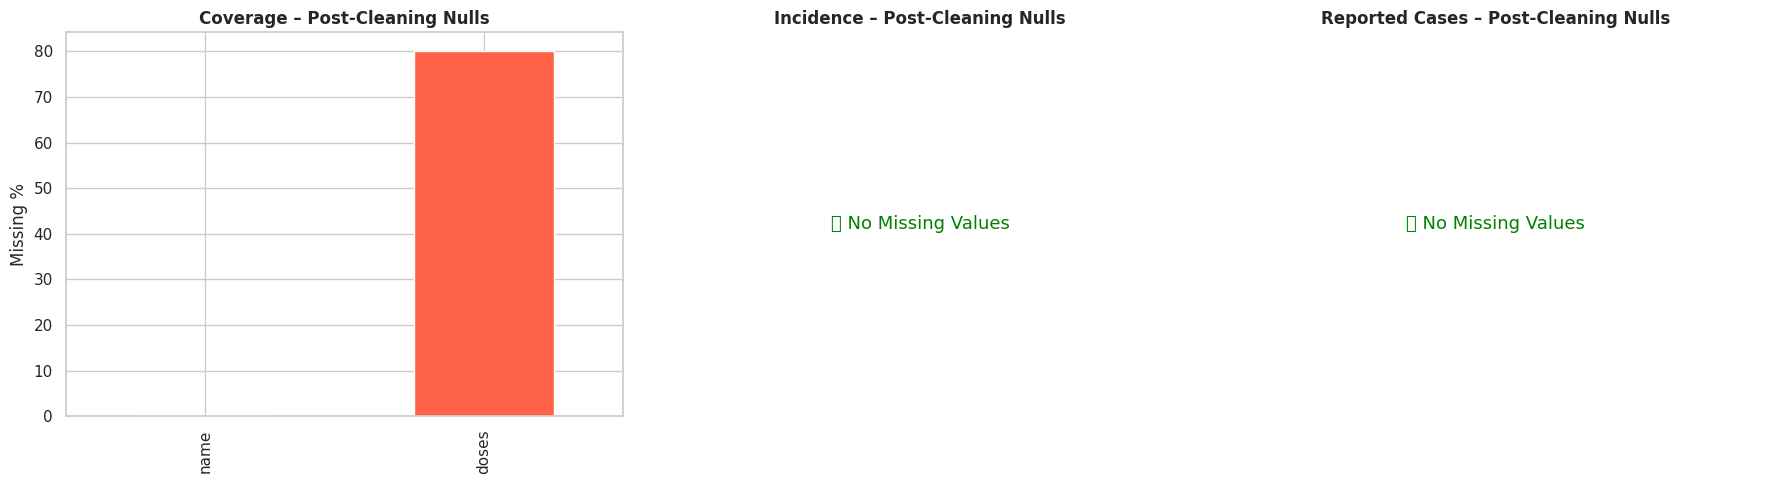

In [14]:
fig, axes = plt.subplots(1,3,figsize=(18,5))
for ax,(n,df) in zip(axes,[('Coverage',df_cov),('Incidence',df_inc),('Reported Cases',df_rep)]):
    miss = df.isnull().mean()*100; miss=miss[miss>0]
    if miss.empty:
        ax.text(0.5,0.5,'✅ No Missing Values',ha='center',va='center',fontsize=13,color='green')
        ax.axis('off')
    else:
        miss.plot(kind='bar',ax=ax,color='tomato',edgecolor='white')
        ax.set_ylabel('Missing %')
    ax.set_title(f'{n} – Post-Cleaning Nulls',fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5. 🔍 Exploratory Data Analysis (EDA) <a id='5'></a>

In [15]:
for n,df in [('Coverage',df_cov),('Incidence',df_inc),('Reported Cases',df_rep)]:
    print(f'\n{"="*50}\n  {n}\n{"="*50}')
    display(df.describe(include='all').T)


  Coverage


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
group,399858,8,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,399858.00,<NA>,<NA>,<NA>,2009.21,11.72,1980.00,2002.00,2012.00,2019.00,2023.00
antigen,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
antigen_description,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage_category,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coverage_category_description,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
target_number,399858.00,NaN,NaN,NaN,54949145.20,24074847065.22,0.00,0.00,0.00,0.00,11700000000000.00
doses,79327.00,NaN,NaN,NaN,3467241.12,11256763.03,-222288203.00,14469.00,152212.00,971018.50,126605212.00



  Incidence


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
group,84945,3,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code,84945,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,84945,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,84945.00,<NA>,<NA>,<NA>,2004.10,12.60,1980.00,1994.00,2005.00,2015.00,2023.00
disease,84945,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disease_description,84945,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
denominator,84945,5,"per 1,000,000 total population",61480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
incidence_rate,84945.00,NaN,NaN,NaN,79.83,846.25,0.00,0.00,0.00,2.80,69101.30



  Reported Cases


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
group,84869,3,COUNTRIES,82054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code,84869,221,GLOBAL,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,84869,221,Global,424,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,84869.00,<NA>,<NA>,<NA>,2004.11,12.59,1980.00,1994.00,2005.00,2015.00,2023.00
disease,84869,13,MEASLES,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
disease_description,84869,13,Measles,9196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cases,84869.00,NaN,NaN,NaN,3450.12,53736.46,0.00,0.00,0.00,20.00,4583555.00


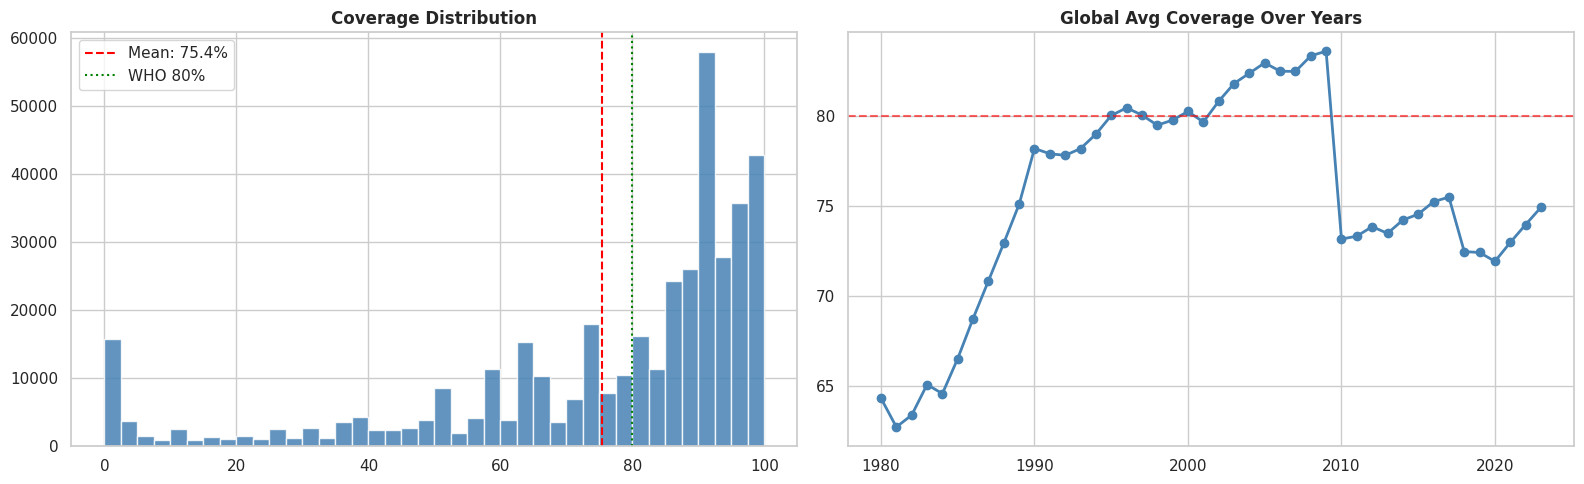

In [16]:
fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].hist(df_cov[COV].dropna(),bins=40,color='steelblue',edgecolor='white',alpha=0.85)
axes[0].axvline(df_cov[COV].mean(),color='red',linestyle='--',label=f'Mean: {df_cov[COV].mean():.1f}%')
axes[0].axvline(80,color='green',linestyle=':',label='WHO 80%')
axes[0].set_title('Coverage Distribution',fontweight='bold'); axes[0].legend()
yr=df_cov.groupby('year')[COV].mean().reset_index()
axes[1].plot(yr['year'],yr[COV],marker='o',color='steelblue',linewidth=2)
axes[1].axhline(80,color='red',linestyle='--',alpha=0.6)
axes[1].set_title('Global Avg Coverage Over Years',fontweight='bold')
plt.tight_layout(); plt.show()

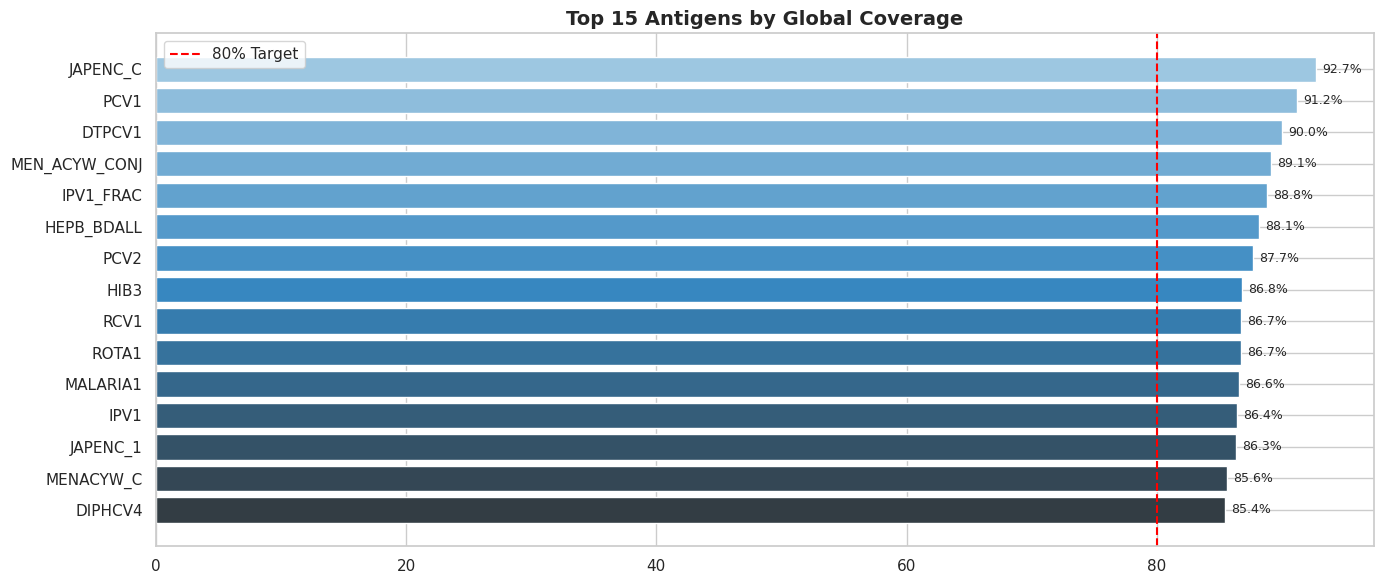

In [17]:
top_ag=df_cov.groupby('antigen')[COV].mean().sort_values(ascending=False).head(15).reset_index()
top_ag.columns=['antigen','avg']
plt.figure(figsize=(14,6))
bars=plt.barh(top_ag['antigen'],top_ag['avg'],color=sns.color_palette('Blues_d',15),edgecolor='white')
plt.axvline(80,color='red',linestyle='--',label='80% Target')
for bar,val in zip(bars,top_ag['avg']): plt.text(val+0.5,bar.get_y()+bar.get_height()/2,f'{val:.1f}%',va='center',fontsize=9)
plt.title('Top 15 Antigens by Global Coverage',fontsize=14,fontweight='bold'); plt.legend(); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()

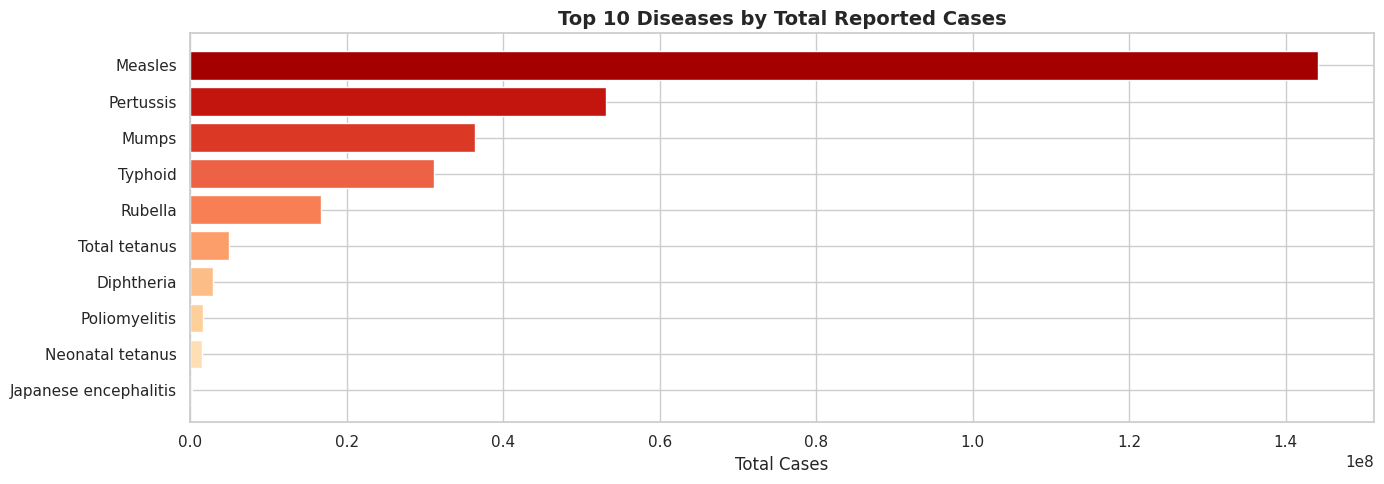

In [18]:
top_d=df_rep.groupby(D_DESC)[CAS].sum().sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(14,5))
plt.barh(top_d[D_DESC],top_d[CAS],color=sns.color_palette('OrRd_r',10),edgecolor='white')
plt.title('Top 10 Diseases by Total Reported Cases',fontsize=14,fontweight='bold')
plt.xlabel('Total Cases'); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

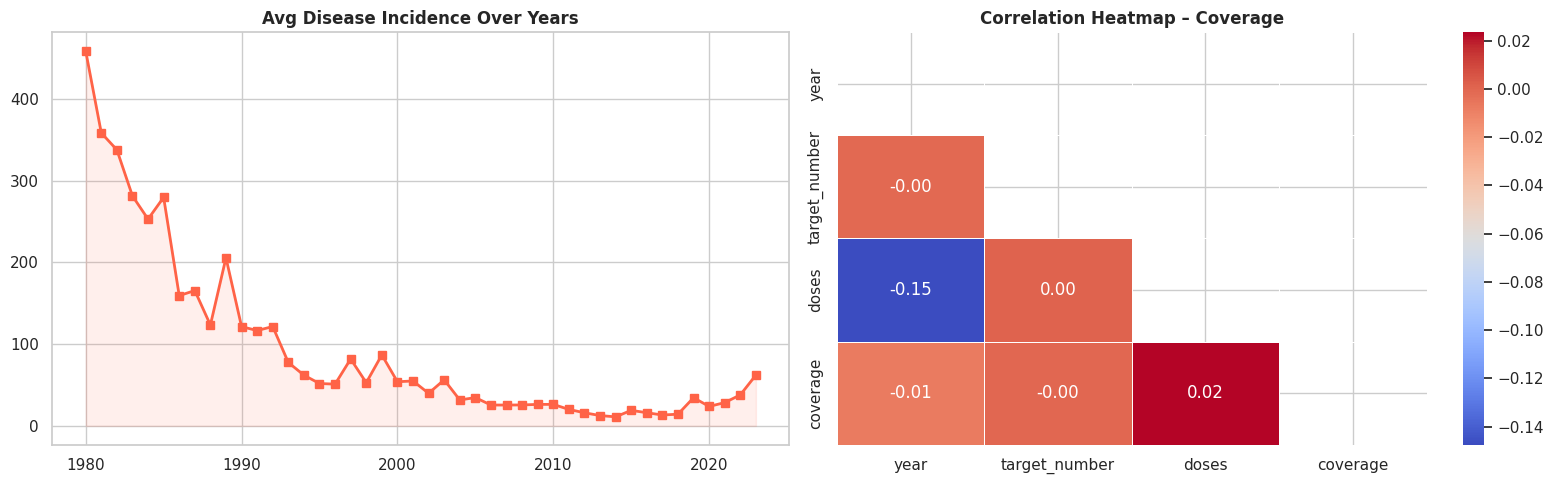

In [19]:
fig,axes=plt.subplots(1,2,figsize=(16,5))
yi=df_inc.groupby('year')[RATE].mean().reset_index()
axes[0].plot(yi['year'],yi[RATE],marker='s',color='tomato',linewidth=2)
axes[0].fill_between(yi['year'],yi[RATE],alpha=0.1,color='tomato')
axes[0].set_title('Avg Disease Incidence Over Years',fontweight='bold')
num_c=df_cov.select_dtypes(include=np.number).columns.tolist()
if len(num_c)>=2:
    corr=df_cov[num_c].corr(); mask=np.triu(np.ones_like(corr,dtype=bool))
    sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm',mask=mask,ax=axes[1],linewidths=0.5)
    axes[1].set_title('Correlation Heatmap – Coverage',fontweight='bold')
plt.tight_layout(); plt.show()

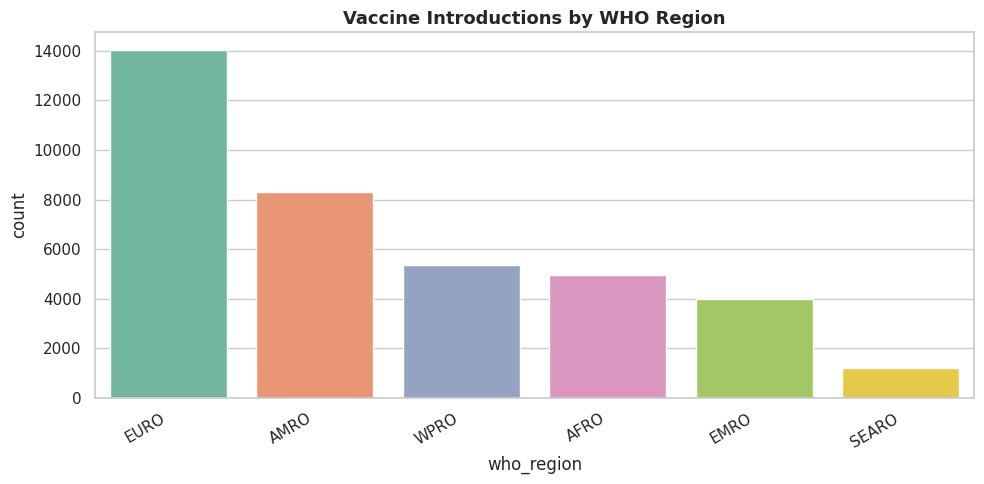

In [20]:
ir=(df_int[df_int['introduced']==1].groupby(WHO)['introduced'].count().sort_values(ascending=False).reset_index())
ir.columns=['who_region','count']
plt.figure(figsize=(10,5))
sns.barplot(data=ir,x='who_region',y='count',palette='Set2',edgecolor='white')
plt.title('Vaccine Introductions by WHO Region',fontsize=13,fontweight='bold')
plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()

In [21]:
merged = pd.merge(
    df_cov.groupby(['code','year'])[COV].mean().reset_index(),
    df_inc.groupby(['code','year'])[RATE].mean().reset_index(),
    on=['code','year'])
country_names = df_cov[['code','name']].drop_duplicates()
print(f'Merged table shape: {merged.shape}')

Merged table shape: (9281, 4)


---
## 6. 🟢 Easy Level Questions (All 10) <a id='6'></a>

### Q1 – Coverage vs Disease Incidence Correlation

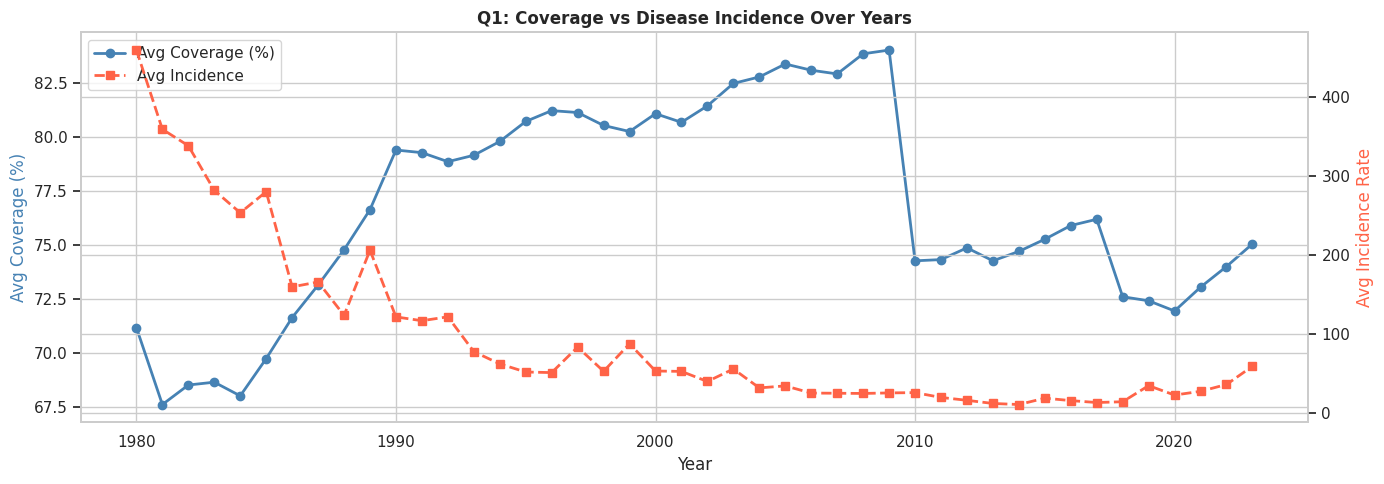

Pearson Correlation: -0.126
→ Higher coverage = Lower incidence ✅


In [22]:
q1=merged.groupby('year').agg(avg_cov=(COV,'mean'),avg_inc=(RATE,'mean')).reset_index()
fig,ax1=plt.subplots(figsize=(14,5)); ax2=ax1.twinx()
ax1.plot(q1['year'],q1['avg_cov'],color='steelblue',marker='o',linewidth=2,label='Avg Coverage (%)')
ax2.plot(q1['year'],q1['avg_inc'],color='tomato',marker='s',linestyle='--',linewidth=2,label='Avg Incidence')
ax1.set_xlabel('Year'); ax1.set_ylabel('Avg Coverage (%)',color='steelblue')
ax2.set_ylabel('Avg Incidence Rate',color='tomato')
lines=ax1.get_lines()+ax2.get_lines()
ax1.legend(lines,[l.get_label() for l in lines],loc='upper left')
plt.title('Q1: Coverage vs Disease Incidence Over Years',fontweight='bold')
plt.tight_layout(); plt.show()
c=merged[[COV,RATE]].corr().iloc[0,1]
print(f'Pearson Correlation: {c:.3f}')
print('→ Higher coverage = Lower incidence ✅' if c<0 else '→ Weak/Positive correlation')

### Q2 – Drop-off Between 1st and Subsequent Doses

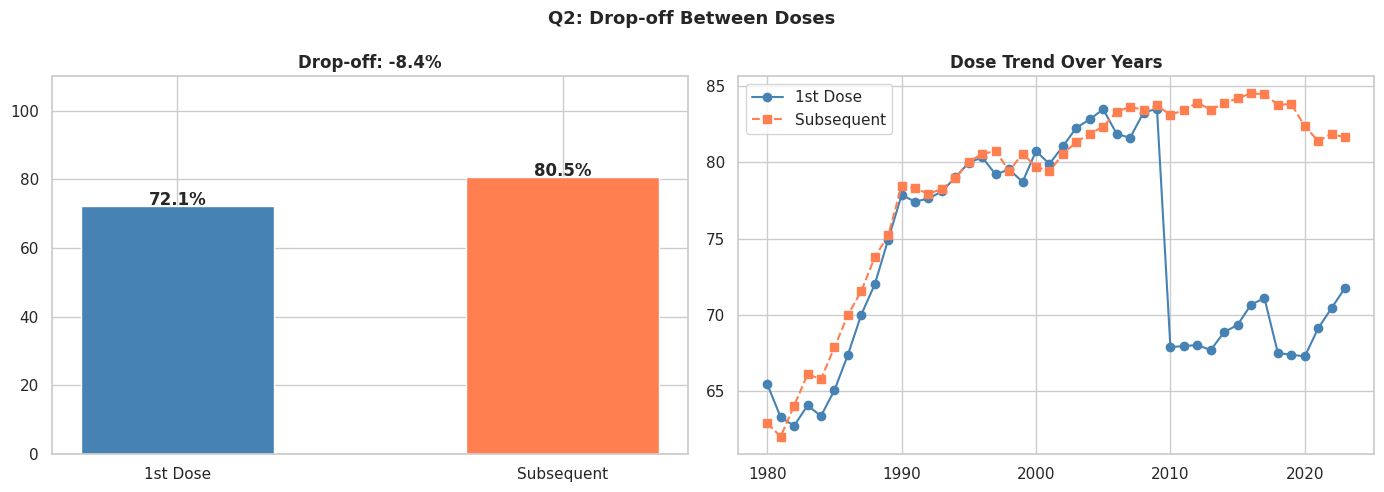

1st Dose: 72.1% | Subsequent: 80.5% | Drop-off: -8.4%


In [23]:
first =df_cov[~df_cov['antigen'].str.contains('2|3|4|booster|bst',case=False,na=False)]
subseq=df_cov[ df_cov['antigen'].str.contains('2|3|4|booster|bst',case=False,na=False)]
a1,as_=first[COV].mean(),subseq[COV].mean()
fig,axes=plt.subplots(1,2,figsize=(14,5))
bars=axes[0].bar(['1st Dose','Subsequent'],[a1,as_],color=['steelblue','coral'],edgecolor='white',width=0.5)
for bar,val in zip(bars,[a1,as_]):
    axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val:.1f}%',ha='center',fontsize=12,fontweight='bold')
axes[0].set_ylim(0,110); axes[0].set_title(f'Drop-off: {a1-as_:.1f}%',fontweight='bold')
t1=first.groupby('year')[COV].mean(); t2=subseq.groupby('year')[COV].mean()
axes[1].plot(t1.index,t1.values,color='steelblue',marker='o',label='1st Dose')
axes[1].plot(t2.index,t2.values,color='coral',marker='s',linestyle='--',label='Subsequent')
axes[1].set_title('Dose Trend Over Years',fontweight='bold'); axes[1].legend()
plt.suptitle('Q2: Drop-off Between Doses',fontsize=13,fontweight='bold'); plt.tight_layout(); plt.show()
print(f'1st Dose: {a1:.1f}% | Subsequent: {as_:.1f}% | Drop-off: {a1-as_:.1f}%')

### Q3 – Gender Differences in Vaccination Rates

In [24]:
gender_found = False
for name, df in [('Coverage',df_cov),('Schedule',df_sch),('Introduction',df_int)]:
    gcols = [c for c in df.columns if 'gender' in c or 'sex' in c or 'male' in c or 'female' in c]
    if gcols:
        print(f'Gender column found in {name}: {gcols}')
        gender_found = True

if not gender_found:
    print('Gender column not directly available in this dataset.')
    print('→ WHO vaccination data is aggregated at country level, not individual level.')
    print('→ Gender-disaggregated data requires survey-level datasets (e.g., DHS, MICS).')
    if 'target_pop_description' in df_sch.columns:
        tpd = df_sch['target_pop_description'].value_counts().head(10)
        tpd.plot(kind='bar',color='teal',edgecolor='white',figsize=(12,5))
        plt.title('Q3: Target Population Breakdown (Gender Proxy)',fontweight='bold')
        plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

Gender column not directly available in this dataset.
→ WHO vaccination data is aggregated at country level, not individual level.
→ Gender-disaggregated data requires survey-level datasets (e.g., DHS, MICS).


### Q4 – Education Level Impact on Vaccination Rates

In [25]:
edu_found = False
for name, df in [('Coverage',df_cov),('Schedule',df_sch)]:
    ecols = [c for c in df.columns if 'edu' in c or 'literacy' in c]
    if ecols:
        print(f'Education column in {name}: {ecols}'); edu_found = True

if not edu_found:
    print('Education column not available — WHO datasets are country-level aggregates.')
    print('Proxy: Coverage by WHO Region (regions differ in development levels)')
    reg_cov = df_int.merge(df_cov.groupby('code')[COV].mean().reset_index(),left_on=ISO,right_on='code',how='left')
    if COV in reg_cov.columns:
        rc = reg_cov.groupby(WHO)[COV].mean().sort_values(ascending=False).reset_index()
        plt.figure(figsize=(10,5))
        sns.barplot(data=rc,x=WHO,y=COV,palette='viridis',edgecolor='white')
        plt.title('Q4: Avg Coverage by WHO Region (Education/Development Proxy)',fontweight='bold')
        plt.xlabel('WHO Region'); plt.ylabel('Avg Coverage (%)'); plt.xticks(rotation=30,ha='right')
        plt.tight_layout(); plt.show()

Education column in Schedule: ['schedulerounds']


### Q5 – Urban vs Rural Vaccination Rate Difference

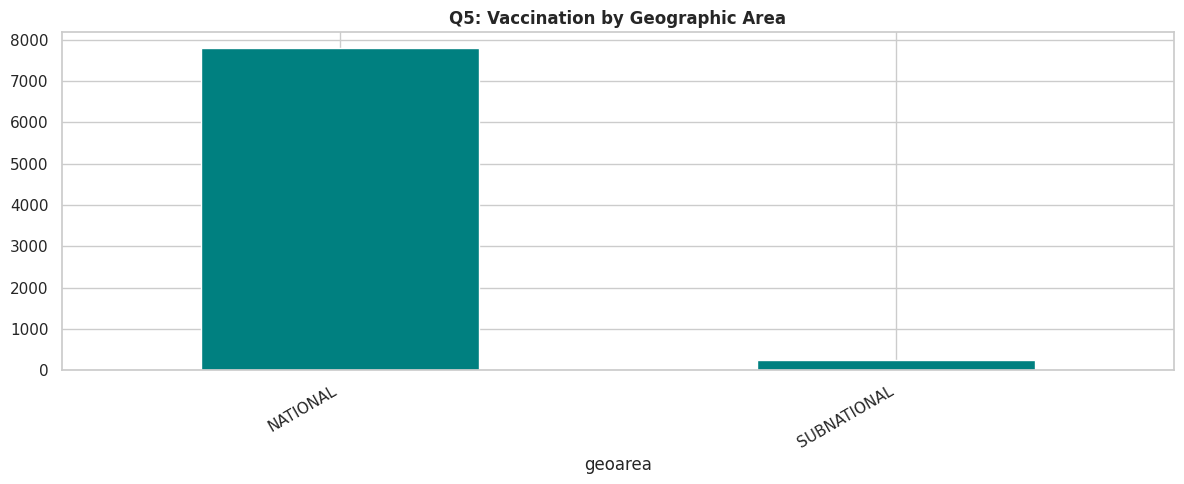

In [26]:
if GEO:
    geo_vals = df_sch[GEO].value_counts().head(10)
    geo_vals.plot(kind='bar',color='teal',edgecolor='white',figsize=(12,5))
    plt.title('Q5: Vaccination by Geographic Area',fontweight='bold')
    plt.xticks(rotation=30,ha='right'); plt.tight_layout(); plt.show()
elif CAT:
    urban = df_cov.groupby(CAT)[COV].agg(['mean','count','std']).round(2)
    urban.columns=['Avg Coverage %','Count','Std Dev']
    display(urban)
    urban['Avg Coverage %'].plot(kind='bar',color='teal',edgecolor='white',figsize=(10,5))
    plt.title('Q5: Coverage by Category (Urban/Rural Proxy)',fontweight='bold')
    plt.xticks(rotation=30,ha='right'); plt.ylabel('Avg Coverage (%)'); plt.tight_layout(); plt.show()
else:
    print('Urban/Rural geographic split not available; dataset is country-level aggregate.')

### Q6 – Booster Dose Uptake Over Time

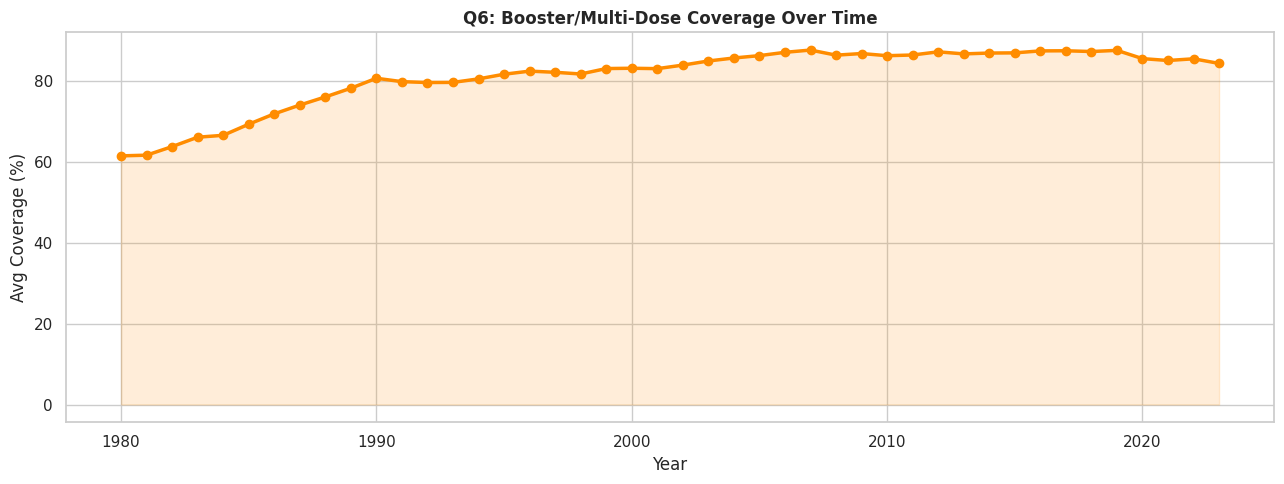

Start: 61.5% | End: 84.4% | Trend: ↑ Increased


In [27]:
booster=df_cov[df_cov['antigen'].str.contains('booster|bst|3|4',case=False,na=False)]
if len(booster)>0:
    bt=booster.groupby('year')[COV].mean().reset_index()
    plt.figure(figsize=(13,5))
    plt.plot(bt['year'],bt[COV],marker='o',color='darkorange',linewidth=2.5)
    plt.fill_between(bt['year'],bt[COV],alpha=0.15,color='darkorange')
    plt.title('Q6: Booster/Multi-Dose Coverage Over Time',fontweight='bold')
    plt.xlabel('Year'); plt.ylabel('Avg Coverage (%)')
    plt.tight_layout(); plt.show()
    f,l=bt[COV].iloc[0],bt[COV].iloc[-1]
    print(f'Start: {f:.1f}% | End: {l:.1f}% | Trend: {"↑ Increased" if l>f else "↓ Decreased"}')

### Q7 – Seasonal Pattern in Vaccination Uptake

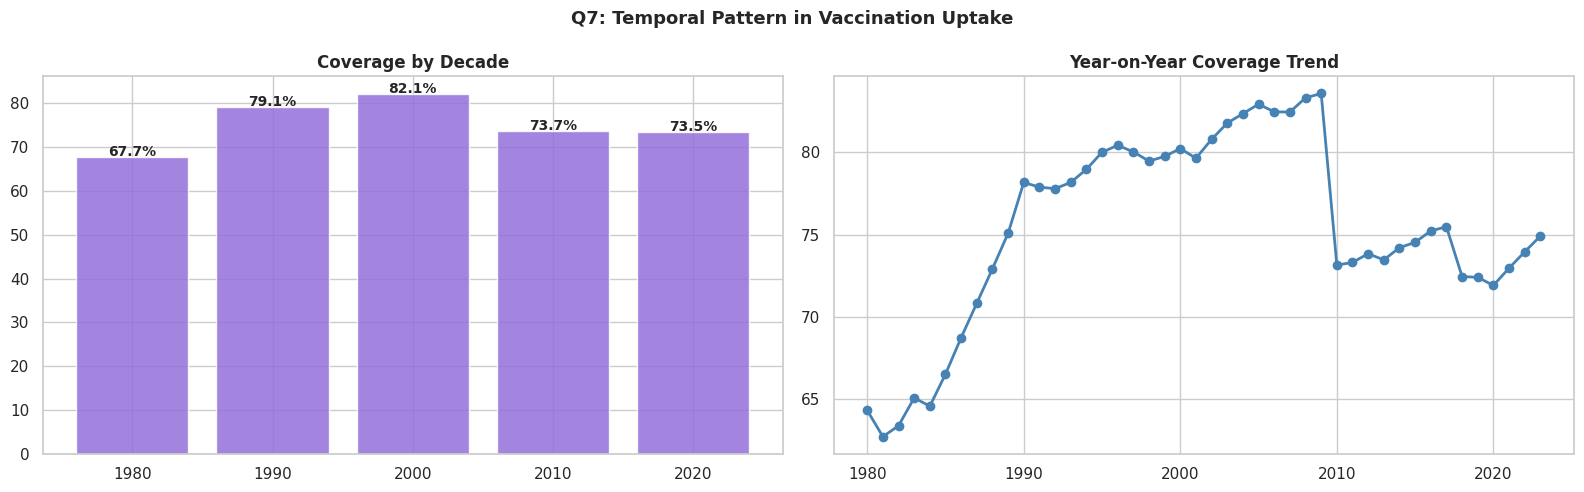

In [28]:
seasonal_tmp = df_cov.copy()
seasonal_tmp['decade']=(seasonal_tmp['year']//10)*10
seasonal=seasonal_tmp.groupby('decade')[COV].mean().reset_index()
fig,axes=plt.subplots(1,2,figsize=(16,5))
bars=axes[0].bar(seasonal['decade'].astype(str),seasonal[COV],color='mediumpurple',edgecolor='white',alpha=0.85)
for bar,val in zip(bars,seasonal[COV]):
    axes[0].text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.3,f'{val:.1f}%',ha='center',fontsize=10,fontweight='bold')
axes[0].set_title('Coverage by Decade',fontweight='bold')
yr_cov=df_cov.groupby('year')[COV].mean().reset_index()
axes[1].plot(yr_cov['year'],yr_cov[COV],marker='o',color='steelblue',linewidth=2)
axes[1].set_title('Year-on-Year Coverage Trend',fontweight='bold')
plt.suptitle('Q7: Temporal Pattern in Vaccination Uptake',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

### Q8 – Population Density vs Vaccination Coverage

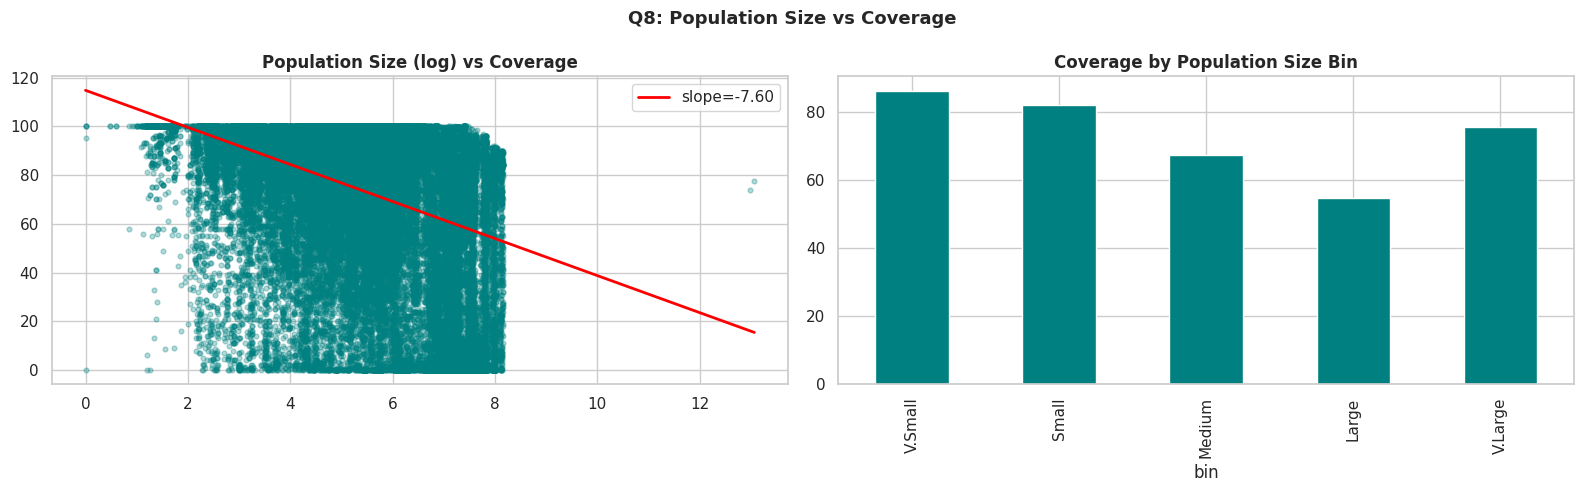

In [29]:
if TGT:
    tc=df_cov[[TGT,COV]].dropna(); tc=tc[tc[TGT]>0].copy()
    tc['log_t']=np.log10(tc[TGT])
    fig,axes=plt.subplots(1,2,figsize=(16,5))
    axes[0].scatter(tc['log_t'],tc[COV],alpha=0.3,color='teal',s=12)
    m,b=np.polyfit(tc['log_t'],tc[COV],1); xs=np.linspace(tc['log_t'].min(),tc['log_t'].max(),100)
    axes[0].plot(xs,m*xs+b,color='red',linewidth=2,label=f'slope={m:.2f}')
    axes[0].set_title('Population Size (log) vs Coverage',fontweight='bold'); axes[0].legend()
    tc['bin']=pd.cut(tc['log_t'],bins=5,labels=['V.Small','Small','Medium','Large','V.Large'])
    tc.groupby('bin')[COV].mean().plot(kind='bar',ax=axes[1],color='teal',edgecolor='white')
    axes[1].set_title('Coverage by Population Size Bin',fontweight='bold')
    plt.suptitle('Q8: Population Size vs Coverage',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.show()

### Q9 – Vaccination Rate vs Disease Incidence (Detailed)

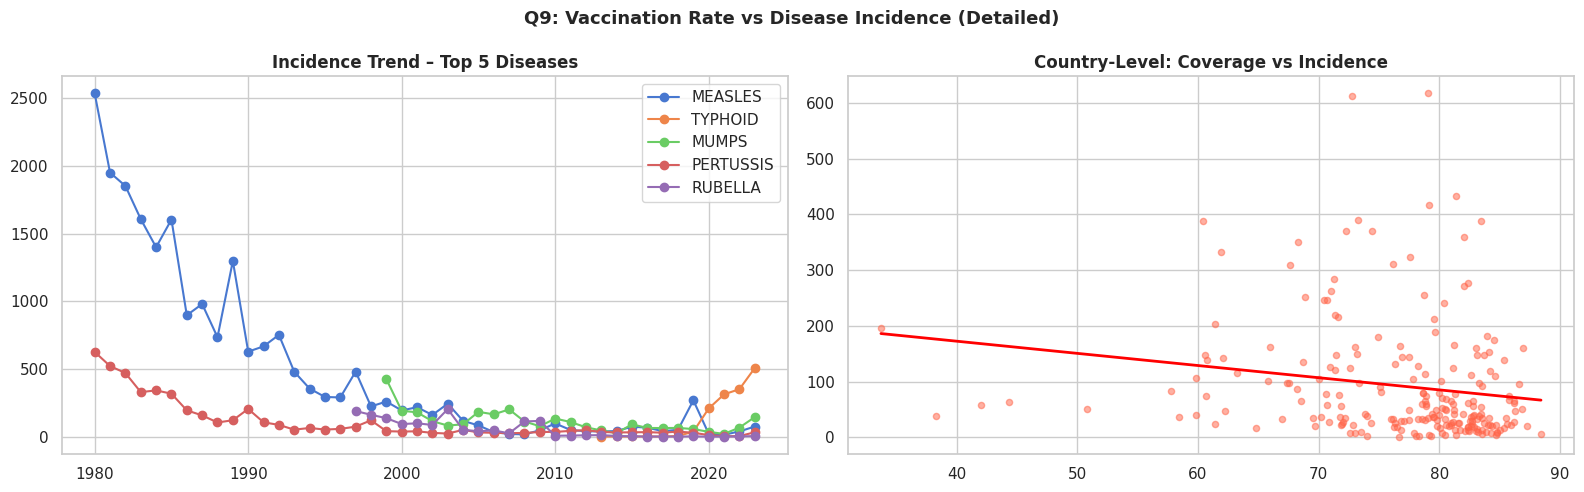

Country-level correlation: -0.176


In [30]:
top5d=df_inc.groupby(DIS_I)[RATE].mean().sort_values(ascending=False).head(5).index.tolist()
fig,axes=plt.subplots(1,2,figsize=(16,5))
for dis in top5d:
    d_inc=df_inc[df_inc[DIS_I]==dis].groupby('year')[RATE].mean()
    axes[0].plot(d_inc.index,d_inc.values,marker='o',label=dis)
axes[0].set_title('Incidence Trend – Top 5 Diseases',fontweight='bold'); axes[0].legend()
sc=merged.groupby('code').agg(avg_cov=(COV,'mean'),avg_inc=(RATE,'mean')).reset_index()
sc=sc.merge(country_names,on='code',how='left')
axes[1].scatter(sc['avg_cov'],sc['avg_inc'],alpha=0.5,color='tomato',s=20)
m2,b2=np.polyfit(sc['avg_cov'].dropna(),sc['avg_inc'].dropna(),1)
xs2=np.linspace(sc['avg_cov'].min(),sc['avg_cov'].max(),100)
axes[1].plot(xs2,m2*xs2+b2,color='red',linewidth=2)
axes[1].set_title('Country-Level: Coverage vs Incidence',fontweight='bold')
plt.suptitle('Q9: Vaccination Rate vs Disease Incidence (Detailed)',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()
print(f'Country-level correlation: {sc[["avg_cov","avg_inc"]].corr().iloc[0,1]:.3f}')

### Q10 – High Incidence Despite High Coverage

Countries with >=75% coverage but high incidence: 15


,name,avg_cov,avg_inc
138,Malawi,79.09,617.09
201,Tuvalu,81.39,432.45
219,Zambia,79.15,416.81
151,Oman,83.46,387.43
43,Cook Islands,82.02,359.30
185,Eswatini,77.56,323.00
32,Bhutan,76.20,311.29
145,Niue,82.37,276.42
213,Wallis and Futuna,82.06,271.27
167,Rwanda,78.73,255.81


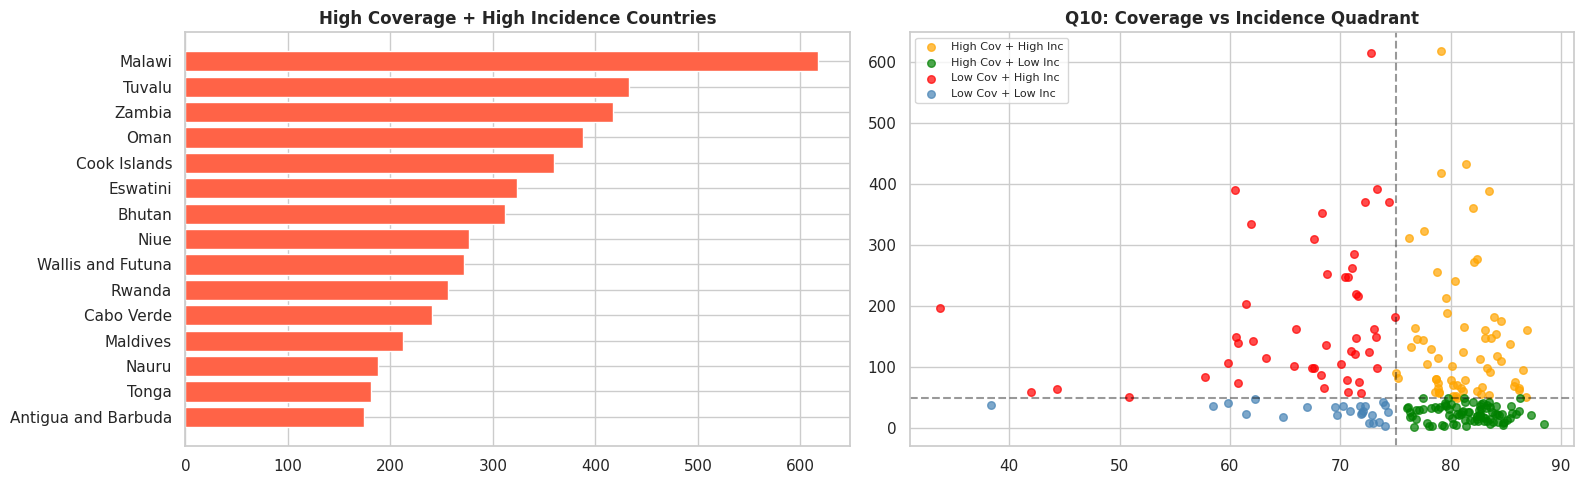

In [31]:
q10=merged.groupby('code').agg(avg_cov=(COV,'mean'),avg_inc=(RATE,'mean')).reset_index()
q10=q10.merge(country_names,on='code',how='left')
hi=q10[(q10['avg_cov']>=75)&(q10['avg_inc']>=q10['avg_inc'].quantile(0.6))].sort_values('avg_inc',ascending=False).head(15)
print(f'Countries with >=75% coverage but high incidence: {len(hi)}')
display(hi[['name','avg_cov','avg_inc']].round(2))
fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].barh(hi['name'],hi['avg_inc'],color='tomato',edgecolor='white')
axes[0].set_title('High Coverage + High Incidence Countries',fontweight='bold'); axes[0].invert_yaxis()
q=q10.copy(); q['quadrant']='Low Cov + Low Inc'
q.loc[(q['avg_cov']>=75)&(q['avg_inc']>=q['avg_inc'].median()),'quadrant']='High Cov + High Inc'
q.loc[(q['avg_cov']>=75)&(q['avg_inc']<q['avg_inc'].median()),'quadrant']='High Cov + Low Inc'
q.loc[(q['avg_cov']<75)&(q['avg_inc']>=q['avg_inc'].median()),'quadrant']='Low Cov + High Inc'
colors={'High Cov + High Inc':'orange','High Cov + Low Inc':'green','Low Cov + High Inc':'red','Low Cov + Low Inc':'steelblue'}
for quad,grp in q.groupby('quadrant'):
    axes[1].scatter(grp['avg_cov'],grp['avg_inc'],label=quad,color=colors.get(quad,'grey'),alpha=0.7,s=30)
axes[1].axvline(75,color='black',linestyle='--',alpha=0.4); axes[1].axhline(q['avg_inc'].median(),color='black',linestyle='--',alpha=0.4)
axes[1].set_title('Q10: Coverage vs Incidence Quadrant',fontweight='bold'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 7. 🟡 Medium Level Questions (All 10) <a id='7'></a>

### M1 – Vaccine Introduction vs Disease Case Decrease

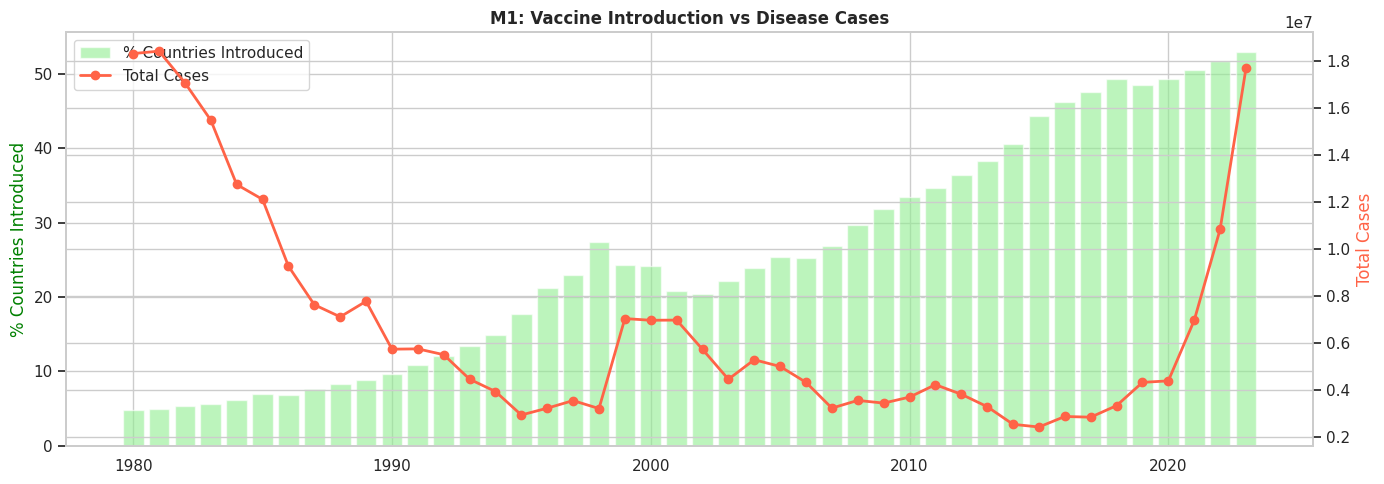

Correlation: -0.408


In [32]:
iy=df_int.groupby('year')['introduced'].mean().reset_index(); iy.columns=['year','pct_intro']
cy=df_rep.groupby('year')[CAS].sum().reset_index(); cy.columns=['year','total_cases']
m1=pd.merge(iy,cy,on='year')
fig,ax1=plt.subplots(figsize=(14,5)); ax2=ax1.twinx()
ax1.bar(m1['year'],m1['pct_intro']*100,color='lightgreen',alpha=0.6,label='% Countries Introduced')
ax2.plot(m1['year'],m1['total_cases'],color='tomato',marker='o',linewidth=2,label='Total Cases')
ax1.set_ylabel('% Countries Introduced',color='green'); ax2.set_ylabel('Total Cases',color='tomato')
l1,lb1=ax1.get_legend_handles_labels(); l2,lb2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,lb1+lb2,loc='upper left')
plt.title('M1: Vaccine Introduction vs Disease Cases',fontweight='bold'); plt.tight_layout(); plt.show()
print(f'Correlation: {m1[["pct_intro","total_cases"]].corr().iloc[0,1]:.3f}')

### M2 – Disease Trends Before vs After Vaccination Campaigns

In [33]:
mid=df_rep['year'].median()
top5d2=df_rep.groupby(D_DESC)[CAS].sum().sort_values(ascending=False).head(5).index.tolist()
m2=df_rep[df_rep[D_DESC].isin(top5d2)].groupby(['year',D_DESC])[CAS].sum().reset_index()
fig=px.line(m2,x='year',y=CAS,color=D_DESC,markers=True,
            title='M2: Disease Trends Before & After Vaccination Campaigns',
            labels={CAS:'Reported Cases','year':'Year',D_DESC:'Disease'})
fig.add_vline(x=mid,line_dash='dash',line_color='red',annotation_text='Midpoint')
fig.update_layout(height=450); fig.show()

### M3 – Diseases with Most Significant Case Reduction

,disease_description,early,recent,reduction_pct
0,Poliomyelitis,1580506.00,42765.00,97.30
1,Measles,127267669.00,16798004.00,86.80
2,Neonatal tetanus,1287049.00,216753.00,83.20
3,Total tetanus,4166097.00,721914.00,82.70
4,Pertussis,45101834.00,7988030.00,82.30
5,Diphtheria,2429988.00,478263.00,80.30
6,Rubella,12516605.00,4139058.00,66.90
7,Yellow fever,97257.00,35421.00,63.60
8,Mumps,10832200.00,25494736.00,-135.40
9,Congenital rubella syndrome,1933.00,26717.00,-1282.20


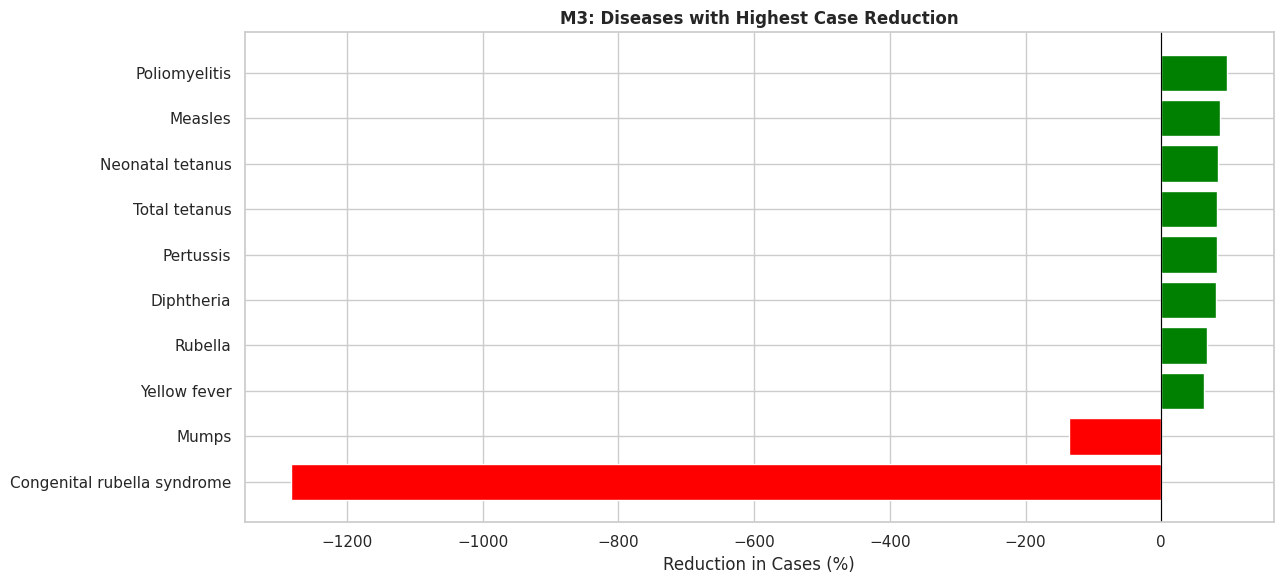

In [34]:
mid_yr=df_rep['year'].median()
early=df_rep[df_rep['year']<=mid_yr].groupby(D_DESC)[CAS].sum()
recent=df_rep[df_rep['year']>mid_yr].groupby(D_DESC)[CAS].sum()
m3=pd.DataFrame({'early':early,'recent':recent}).dropna(); m3=m3[m3['early']>0]
m3['reduction_pct']=((m3['early']-m3['recent'])/m3['early']*100).round(1)
m3=m3.sort_values('reduction_pct',ascending=False).head(10).reset_index()
display(m3)
plt.figure(figsize=(13,6))
colors=['green' if v>0 else 'red' for v in m3['reduction_pct']]
plt.barh(m3[D_DESC],m3['reduction_pct'],color=colors,edgecolor='white')
plt.axvline(0,color='black',linewidth=0.8)
plt.title('M3: Diseases with Highest Case Reduction',fontweight='bold')
plt.xlabel('Reduction in Cases (%)'); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### M4 – Target Population Coverage by Vaccine

In [35]:
m4=df_cov.groupby('antigen')[COV].mean().sort_values(ascending=False).head(20).reset_index()
m4.columns=['antigen','avg_cov']
fig=px.bar(m4,x='avg_cov',y='antigen',orientation='h',color='avg_cov',color_continuous_scale='Blues',
           title='M4: Target Population Coverage % by Vaccine',
           labels={'avg_cov':'Avg Coverage (%)','antigen':'Antigen'})
fig.add_vline(x=80,line_dash='dash',line_color='red',annotation_text='WHO 80%')
fig.add_vline(x=95,line_dash='dot',line_color='green',annotation_text='WHO 95%')
fig.update_layout(height=600,yaxis={'categoryorder':'total ascending'}); fig.show()

### M5 – Vaccination Schedule Impact on Coverage

,dose_round,avg_coverage,countries
0,1.0,76.81,213
1,2.0,76.81,213
2,3.0,76.81,213
3,4.0,76.75,208
4,5.0,76.69,200
5,6.0,77.85,129
6,7.0,81.61,3


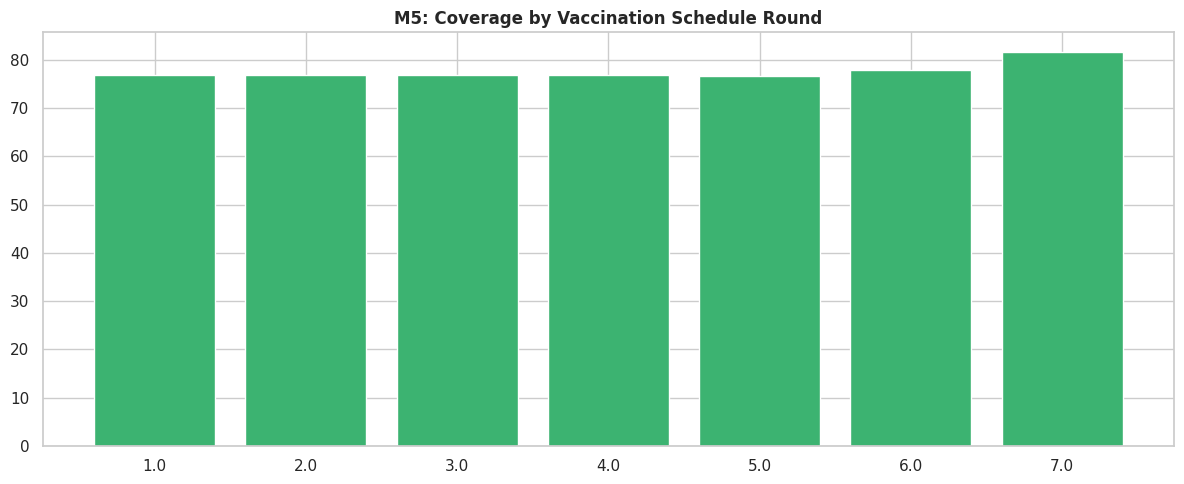

In [36]:
if ROUNDS:
    dose_cov=[]
    for n,grp in df_sch.groupby(ROUNDS):
        codes=grp[ISO].unique()
        cov_sub=df_cov[df_cov['code'].isin(codes)][COV].mean()
        dose_cov.append({'dose_round':str(n),'avg_coverage':round(cov_sub,2),'countries':len(codes)})
    m5=pd.DataFrame(dose_cov).sort_values('dose_round')
    display(m5)
    plt.figure(figsize=(12,5))
    plt.bar(m5['dose_round'],m5['avg_coverage'],color='mediumseagreen',edgecolor='white')
    plt.title('M5: Coverage by Vaccination Schedule Round',fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    f_cov=df_cov[~df_cov['antigen'].str.contains('2|3|booster',case=False,na=False)][COV].mean()
    m_cov=df_cov[df_cov['antigen'].str.contains('2|3|booster',case=False,na=False)][COV].mean()
    vals=[f_cov,m_cov]; labels=['Single/1st Dose','Multi-Dose/Booster']
    plt.figure(figsize=(8,5))
    bars=plt.bar(labels,vals,color=['steelblue','darkorange'],edgecolor='white',width=0.5)
    for bar,val in zip(bars,vals): plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.5,f'{val:.1f}%',ha='center',fontsize=12,fontweight='bold')
    plt.title('M5: Coverage by Schedule Type',fontweight='bold')
    plt.ylabel('Avg Coverage (%)'); plt.ylim(0,110); plt.tight_layout(); plt.show()

### M6 – Vaccine Introduction Disparities Across WHO Regions

,who_region,earliest,latest,avg,count
3,EURO,1955,2023,2009.51,14045
1,AMRO,1940,2023,2011.00,8289
2,EMRO,1963,2023,2011.81,4002
5,WPRO,1970,2023,2011.87,5367
0,AFRO,1979,2023,2014.85,4948
4,SEARO,1992,2023,2015.21,1193


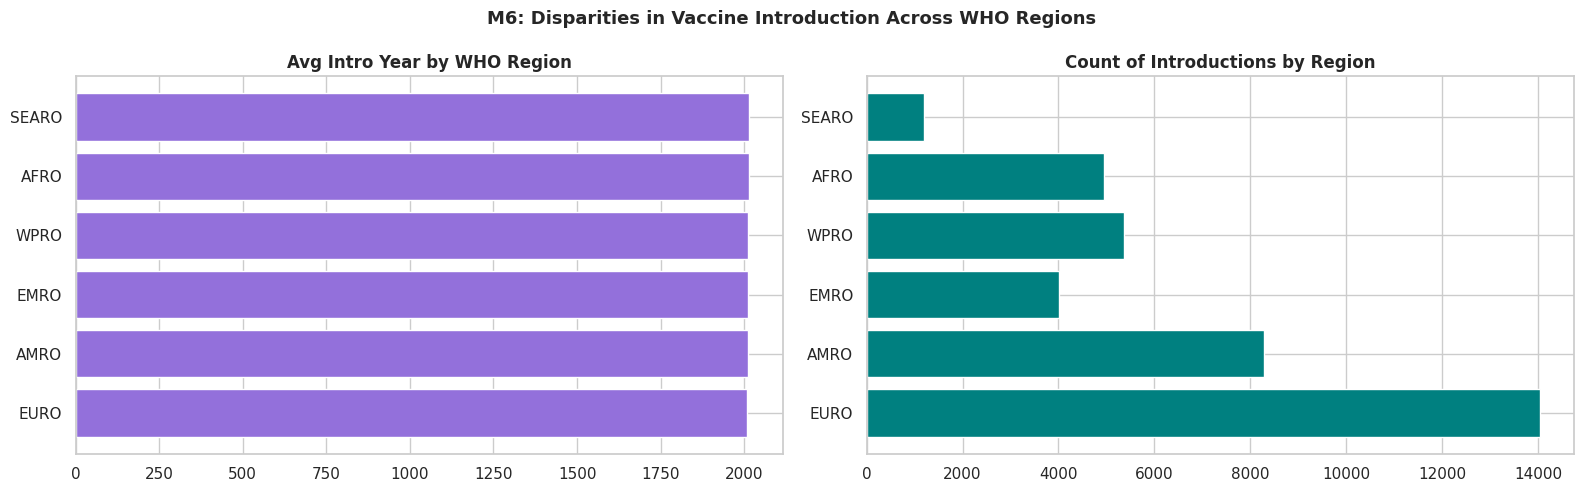

In [37]:
m6=(df_int[df_int['introduced']==1].groupby(WHO)['year']
    .agg(earliest='min',latest='max',avg='mean',count='count').reset_index().sort_values('avg'))
display(m6)
fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].barh(m6[WHO],m6['avg'],color='mediumpurple',edgecolor='white')
axes[0].set_title('Avg Intro Year by WHO Region',fontweight='bold')
axes[1].barh(m6[WHO],m6['count'],color='teal',edgecolor='white')
axes[1].set_title('Count of Introductions by Region',fontweight='bold')
plt.suptitle('M6: Disparities in Vaccine Introduction Across WHO Regions',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

### M7 – Antigen Coverage vs Disease Case Reduction

,antigen,disease,avg_cov,total_cases
0,MCV,MEASLES,81.10,144065673.00
1,POL,POLIO,81.50,1623271.00
2,DTP,DIPHTHERIA,84.80,2908251.00


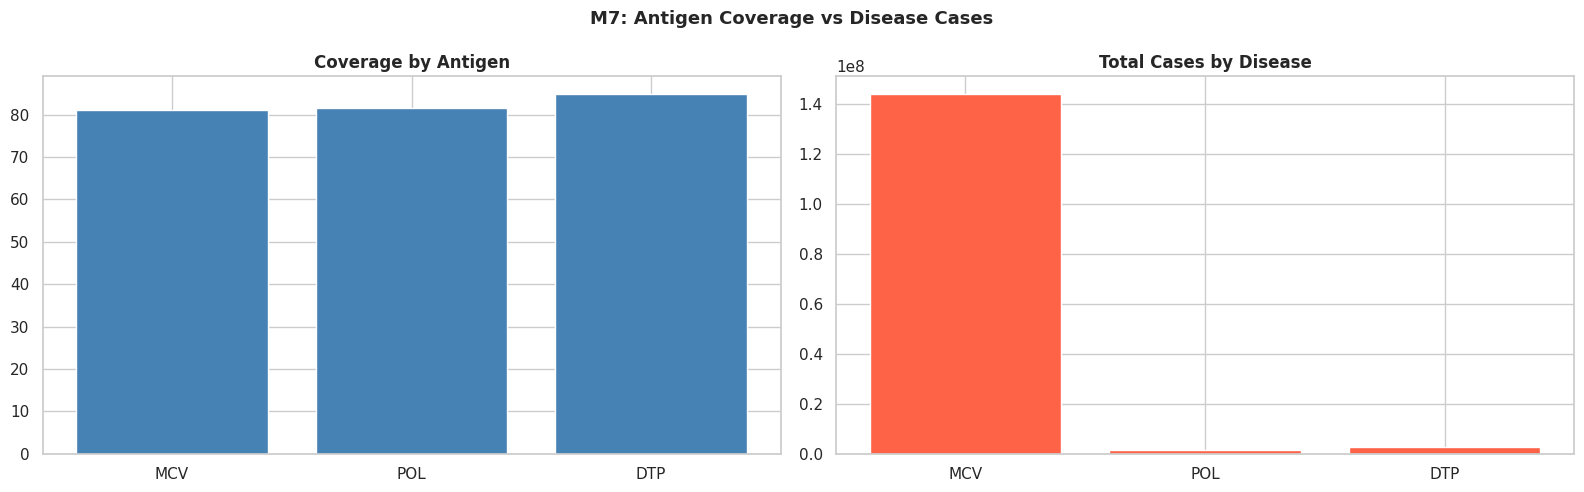

In [38]:
antigen_disease_map = {
    'MCV':'MEASLES','POL':'POLIO','BCG':'TUBERCULOSIS',
    'HEP':'HEPATITIS','HEPB':'HEPATITIS B','DTP':'DIPHTHERIA'
}
results=[]
for ag, disease_kw in antigen_disease_map.items():
    ag_cov=df_cov[df_cov['antigen'].str.upper().str.startswith(ag)][COV].mean() if len(df_cov[df_cov['antigen'].str.upper().str.startswith(ag)])>0 else np.nan
    d_cases=df_rep[df_rep[D_DESC].str.upper().str.contains(disease_kw,na=False)][CAS].sum()
    if not np.isnan(ag_cov) and d_cases>0:
        results.append({'antigen':ag,'disease':disease_kw,'avg_cov':round(ag_cov,1),'total_cases':d_cases})
m7=pd.DataFrame(results).drop_duplicates('antigen') if results else pd.DataFrame()
if not m7.empty:
    display(m7)
    fig,axes=plt.subplots(1,2,figsize=(16,5))
    axes[0].bar(m7['antigen'],m7['avg_cov'],color='steelblue',edgecolor='white')
    axes[0].set_title('Coverage by Antigen',fontweight='bold')
    axes[1].bar(m7['antigen'],m7['total_cases'],color='tomato',edgecolor='white')
    axes[1].set_title('Total Cases by Disease',fontweight='bold')
    plt.suptitle('M7: Antigen Coverage vs Disease Cases',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.show()

### M8 – Low Coverage Despite High Vaccine Availability

Countries with >=5 vaccines but lowest coverage:


,name,avg_cov,vaccines_avail
140,Papua New Guinea,59.80,117
126,Nigeria,61.85,101
28,Central African Republic,62.55,106
157,Somalia,62.64,35
1,Angola,62.85,115
190,Yemen,63.70,110
0,Afghanistan,63.74,92
186,Venezuela (Bolivarian Republic of),64.34,207
168,Chad,65.61,92
60,Micronesia (Federated States of),66.17,291


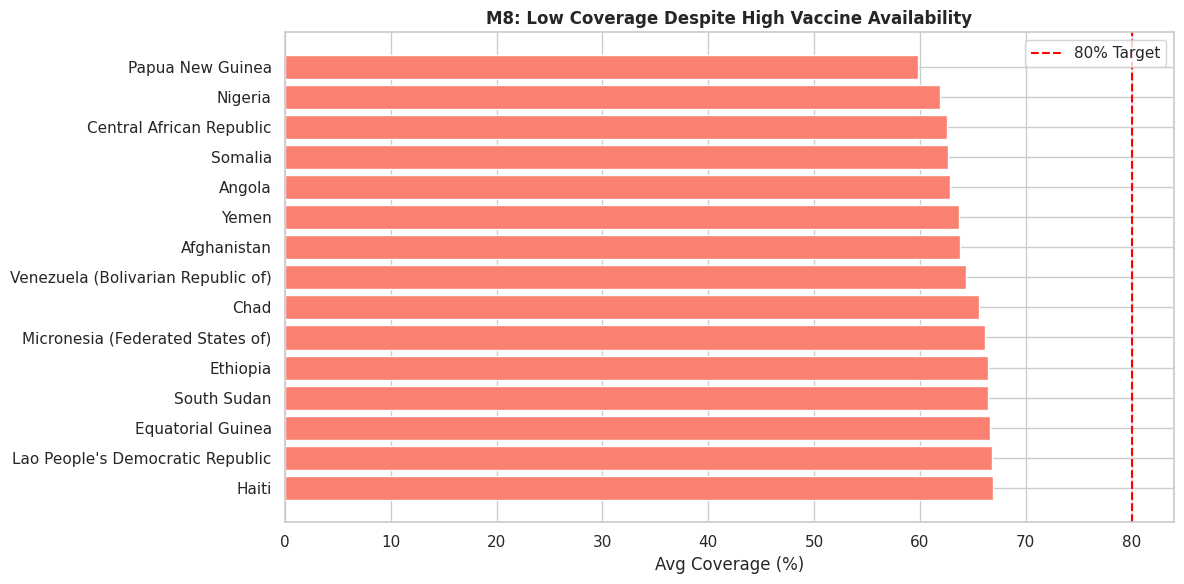

In [39]:
avail=(df_int[df_int['introduced']==1].groupby(ISO)['year'].count().reset_index()
      .rename(columns={ISO:'code','year':'vaccines_avail'}))
c_cov=df_cov.groupby(['code','name'])[COV].mean().reset_index(); c_cov.columns=['code','name','avg_cov']
m8=pd.merge(c_cov,avail,on='code')
m8f=m8[m8['vaccines_avail']>=5].sort_values('avg_cov').head(15)
print('Countries with >=5 vaccines but lowest coverage:'); display(m8f[['name','avg_cov','vaccines_avail']].round(2))
plt.figure(figsize=(12,6))
plt.barh(m8f['name'],m8f['avg_cov'],color='salmon',edgecolor='white')
plt.axvline(80,color='red',linestyle='--',label='80% Target')
plt.title('M8: Low Coverage Despite High Vaccine Availability',fontweight='bold')
plt.xlabel('Avg Coverage (%)'); plt.legend(); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### M9 – Coverage Gaps for High-Priority Diseases

,antigen,avg,min,max,records
12,MCV2X2,25.61,0.00,88.00,621
17,PERCV_PW,63.21,0.00,100.00,1234
8,IPV2,79.50,0.00,100.00,1432
10,MCV1,79.90,0.00,100.00,25939
2,DTPCV3,80.86,0.00,100.00,26015
15,PCV3,81.05,0.00,100.00,10020
18,POL3,81.46,0.00,100.00,26005
9,IPV2_FRAC,82.15,0.00,100.00,2446
11,MCV2,84.44,0.00,100.00,19317
4,HEPB_BD,84.89,0.00,100.00,14982


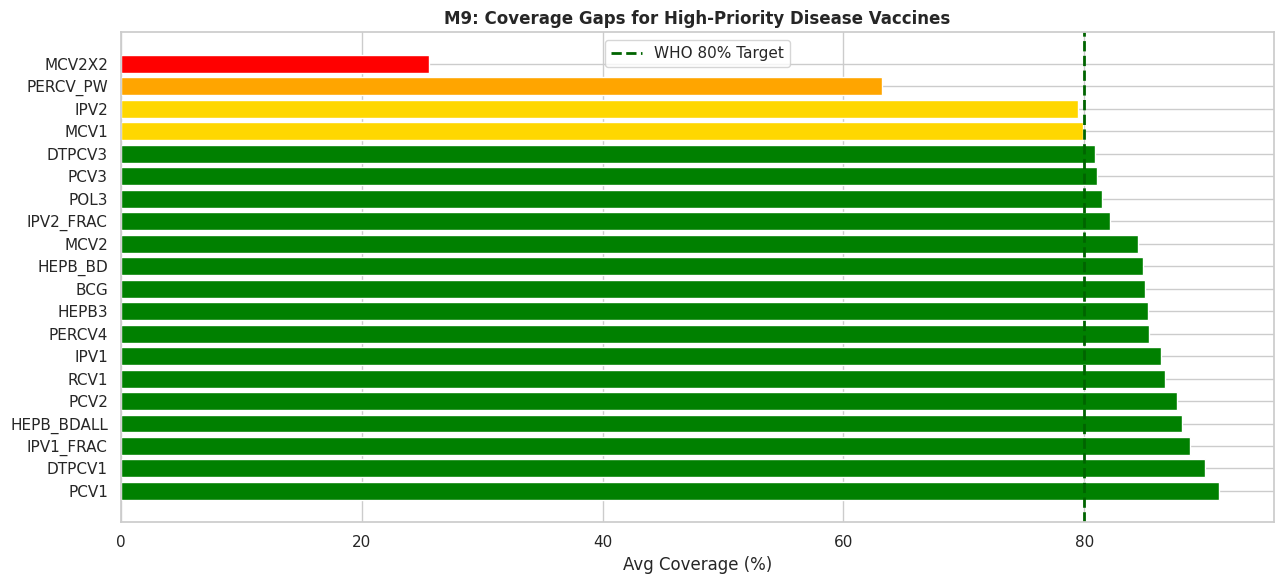

In [40]:
priority=df_cov[df_cov['antigen'].str.upper().str.contains('BCG|HEP|MCV|POL|DTP|PCV|IPV|RCV',na=False)]
p9=priority.groupby('antigen')[COV].agg(['mean','min','max','count']).reset_index().sort_values('mean')
p9.columns=['antigen','avg','min','max','records']
display(p9)
plt.figure(figsize=(13,6))
colors=['red' if v<50 else 'orange' if v<70 else 'gold' if v<80 else 'green' for v in p9['avg']]
plt.barh(p9['antigen'],p9['avg'],color=colors,edgecolor='white')
plt.axvline(80,color='darkgreen',linestyle='--',linewidth=2,label='WHO 80% Target')
plt.title('M9: Coverage Gaps for High-Priority Disease Vaccines',fontweight='bold')
plt.xlabel('Avg Coverage (%)'); plt.legend(); plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

### M10 – Disease Prevalence by Geographic Region

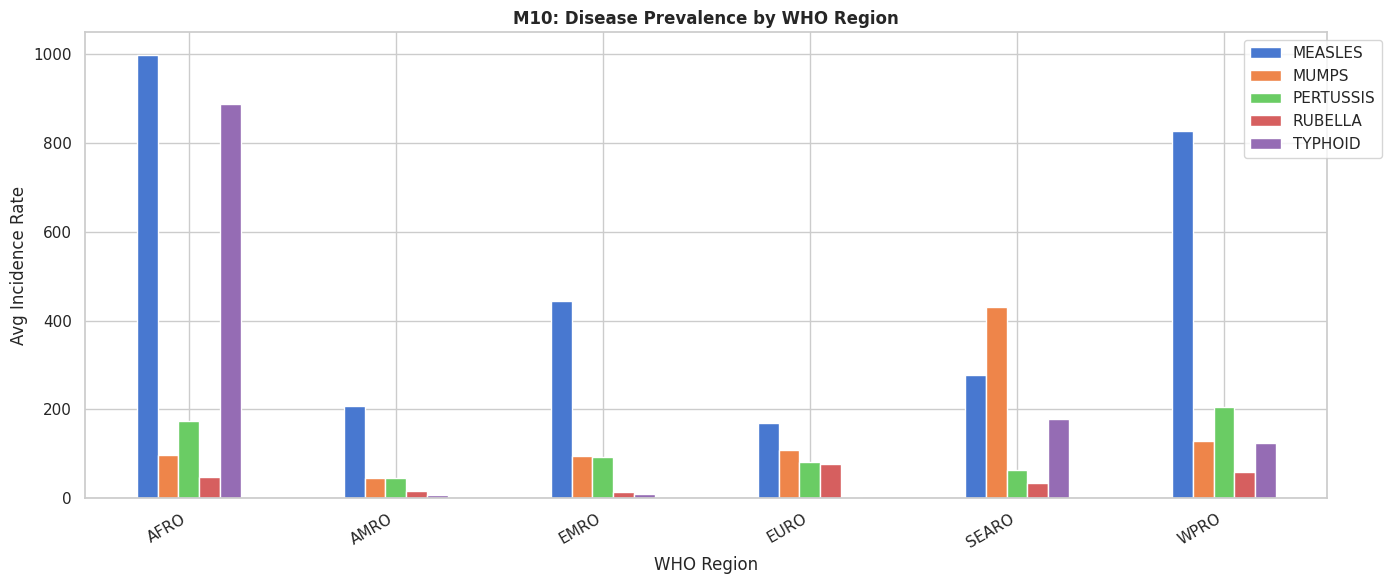

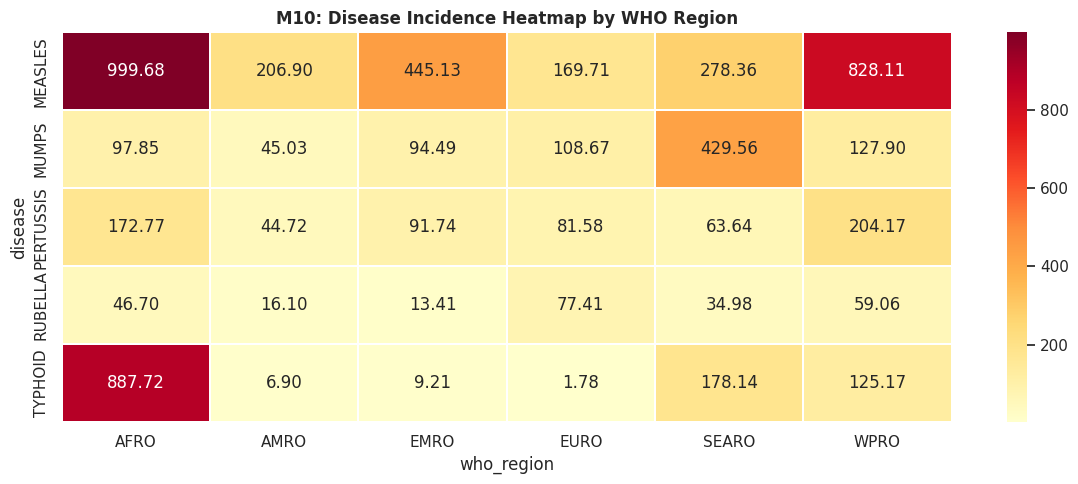

In [41]:
iso_region=df_int[[ISO,WHO]].drop_duplicates().rename(columns={ISO:'code'})
inc_region=df_inc.merge(iso_region,on='code',how='left')
if WHO in inc_region.columns:
    top5dis=df_inc.groupby(DIS_I)[RATE].mean().sort_values(ascending=False).head(5).index.tolist()
    m10=inc_region[inc_region[DIS_I].isin(top5dis)].groupby([WHO,DIS_I])[RATE].mean().unstack().fillna(0)
    m10.plot(kind='bar',figsize=(14,6),edgecolor='white')
    plt.title('M10: Disease Prevalence by WHO Region',fontweight='bold')
    plt.xlabel('WHO Region'); plt.ylabel('Avg Incidence Rate')
    plt.xticks(rotation=30,ha='right'); plt.legend(bbox_to_anchor=(1.05,1)); plt.tight_layout(); plt.show()
    plt.figure(figsize=(12,5))
    sns.heatmap(m10.T,annot=True,fmt='.2f',cmap='YlOrRd',linewidths=0.3)
    plt.title('M10: Disease Incidence Heatmap by WHO Region',fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 8. 🔵 Scenario Based Analysis (All 10) <a id='8'></a>

### Scenario 1 – Resource Allocation by Coverage Priority

In [42]:
s1=df_cov.groupby(['code','name'])[COV].mean().reset_index(); s1.columns=['code','name','avg_cov']; s1=s1.sort_values('avg_cov')
s1['priority']=pd.cut(s1['avg_cov'],bins=[0,50,65,80,100],labels=['Critical (<50%)','Low (50-65%)','Moderate (65-80%)','Good (>=80%)'])
display(s1['priority'].value_counts().reset_index())
display(s1.head(20)[['name','avg_cov','priority']].round(2))
fig=px.choropleth(s1,locations='code',color='avg_cov',hover_name='name',
                  color_continuous_scale='RdYlGn',range_color=(0,100),
                  title='Scenario 1: Resource Allocation Priority Map',labels={'avg_cov':'Coverage (%)'})
fig.update_layout(height=500); fig.show()

,priority,count
0,Moderate (65-80%),131
1,Good (>=80%),77
2,Low (50-65%),19
3,Critical (<50%),16


,name,avg_cov,priority
218,West and Central Africa,29.16,Critical (<50%)
229,Low income,33.52,Critical (<50%)
233,Low income,33.52,Critical (<50%)
76,Gavi 5.0 yes,34.43,Critical (<50%)
119,Least developed,34.46,Critical (<50%)
2,African Region,35.13,Critical (<50%)
217,South Asia,36.19,Critical (<50%)
214,Eastern and Southern Africa,36.28,Critical (<50%)
230,Lower middle income,39.40,Critical (<50%)
176,South-East Asia Region,40.19,Critical (<50%)


### Scenario 2 – Measles Campaign Effectiveness

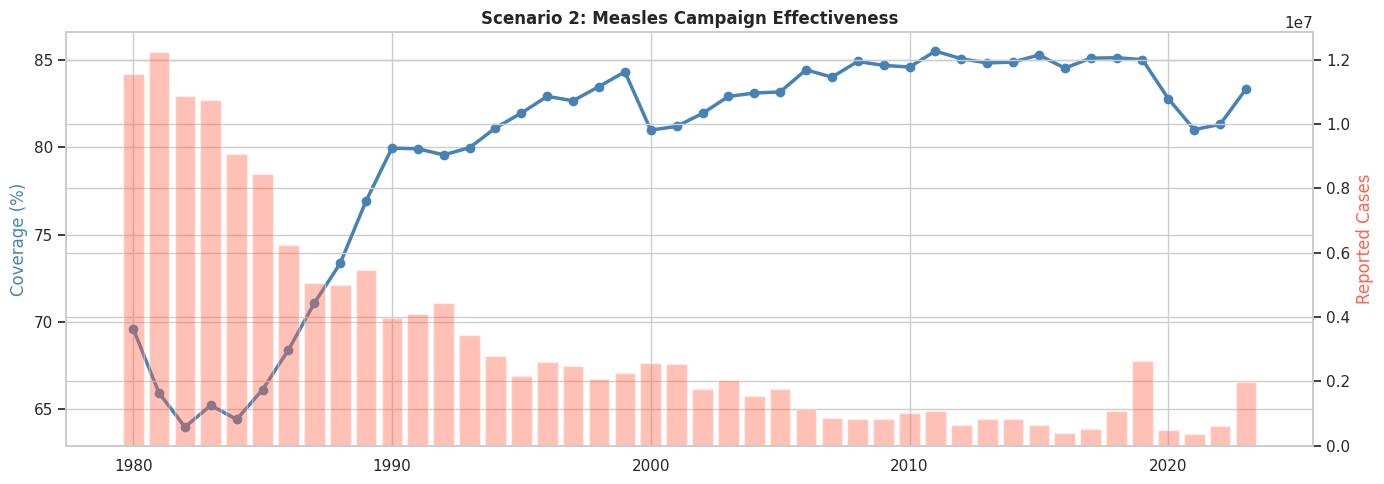

Last 5 yrs avg coverage: 82.7%
Last 5 yrs total cases : 6,075,767


In [43]:
mc=df_cov[df_cov['antigen'].str.upper().str.contains('MCV|MEASLES',na=False)].groupby('year')[COV].mean().reset_index()
mc.columns=['year','mcov']
mcs=df_rep[df_rep[D_DESC].str.upper().str.contains('MEASLES',na=False)].groupby('year')[CAS].sum().reset_index()
mcs.columns=['year','mcases']
if len(mc)>0 and len(mcs)>0:
    s2=pd.merge(mc,mcs,on='year')
    fig,ax1=plt.subplots(figsize=(14,5)); ax2=ax1.twinx()
    ax1.plot(s2['year'],s2['mcov'],color='steelblue',marker='o',linewidth=2.5,label='Measles Coverage %')
    ax2.bar(s2['year'],s2['mcases'],color='tomato',alpha=0.4,label='Measles Cases')
    ax1.set_ylabel('Coverage (%)',color='steelblue'); ax2.set_ylabel('Reported Cases',color='tomato')
    plt.title('Scenario 2: Measles Campaign Effectiveness',fontweight='bold'); plt.tight_layout(); plt.show()
    recent_5=s2.tail(5)
    print(f'Last 5 yrs avg coverage: {recent_5["mcov"].mean():.1f}%')
    print(f'Last 5 yrs total cases : {int(recent_5["mcases"].sum()):,}')
else:
    print('Measles data not found — check antigen/disease column values')

### Scenario 3 – Vaccine Demand Forecast

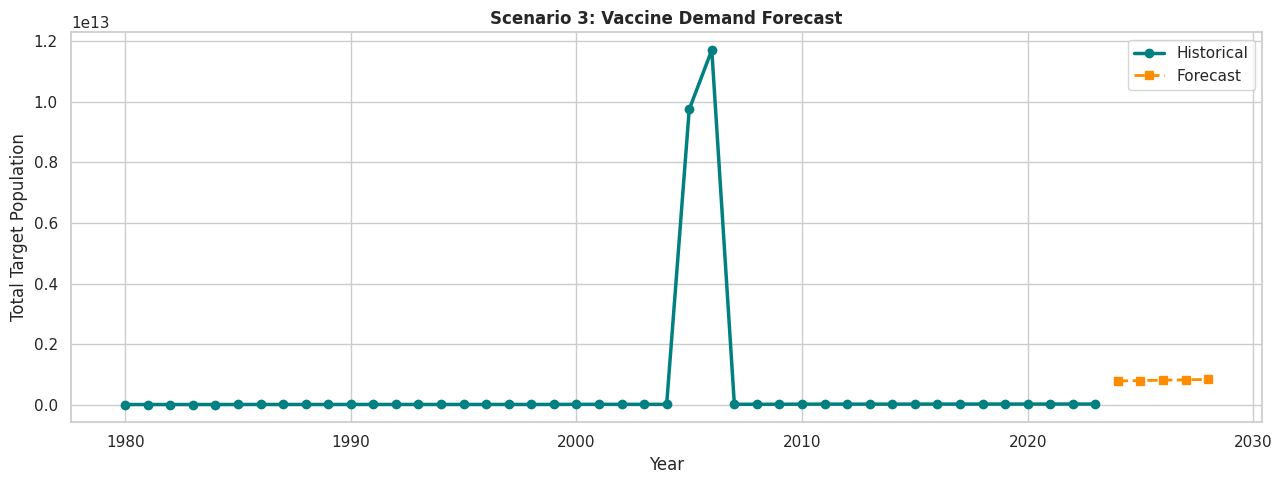

Forecasted Demand:
  2024: 783,982,902,963
  2025: 796,632,794,305
  2026: 809,282,685,647
  2027: 821,932,576,988
  2028: 834,582,468,330


In [44]:
if TGT:
    dem=df_cov.groupby('year')[TGT].sum().reset_index()
    dem[TGT]=pd.to_numeric(dem[TGT],errors='coerce').fillna(0); dem=dem[dem[TGT]>0]
    c=np.polyfit(dem['year'],dem[TGT],1)
    fy=list(range(int(dem['year'].max())+1,int(dem['year'].max())+6))
    fd=[c[0]*y+c[1] for y in fy]
    plt.figure(figsize=(13,5))
    plt.plot(dem['year'],dem[TGT],marker='o',color='teal',linewidth=2.5,label='Historical')
    plt.plot(fy,fd,marker='s',linestyle='--',color='darkorange',linewidth=2,label='Forecast')
    plt.title('Scenario 3: Vaccine Demand Forecast',fontweight='bold')
    plt.xlabel('Year'); plt.ylabel('Total Target Population'); plt.legend(); plt.tight_layout(); plt.show()
    print('Forecasted Demand:')
    for yr,d in zip(fy,fd): print(f'  {yr}: {int(d):,}')

### Scenario 4 – Influenza Outbreak Pattern

Influenza not in dataset — showing top disease instead:


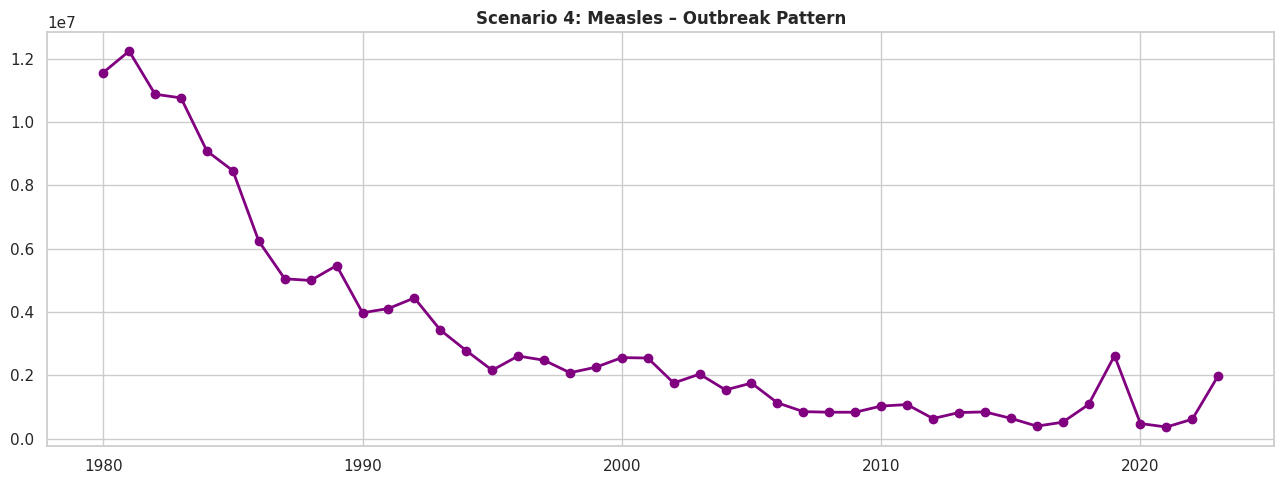

In [45]:
flu=df_rep[df_rep[D_DESC].str.upper().str.contains('INFLUENZA|FLU',na=False)]
if len(flu)>0:
    flu_t=flu.groupby('year')[CAS].sum().reset_index()
    plt.figure(figsize=(13,5))
    plt.plot(flu_t['year'],flu_t[CAS],marker='o',color='purple',linewidth=2.5)
    plt.fill_between(flu_t['year'],flu_t[CAS],alpha=0.15,color='purple')
    peak_yr=flu_t.loc[flu_t[CAS].idxmax(),'year']
    plt.axvline(peak_yr,color='red',linestyle='--',label=f'Peak Year: {int(peak_yr)}')
    plt.title('Scenario 4: Influenza Cases – Outbreak Pattern',fontweight='bold')
    plt.legend(); plt.tight_layout(); plt.show()
    display(flu_t.sort_values(CAS,ascending=False).head(5))
else:
    print('Influenza not in dataset — showing top disease instead:')
    top1=df_rep.groupby(D_DESC)[CAS].sum().idxmax()
    t=df_rep[df_rep[D_DESC]==top1].groupby('year')[CAS].sum().reset_index()
    plt.figure(figsize=(13,5))
    plt.plot(t['year'],t[CAS],marker='o',color='purple',linewidth=2)
    plt.title(f'Scenario 4: {top1} – Outbreak Pattern',fontweight='bold'); plt.tight_layout(); plt.show()

### Scenario 5 – Polio Incidence with No Vaccination Coverage

Countries with <30% polio coverage: 0


,name,polio_cov,polio_rate


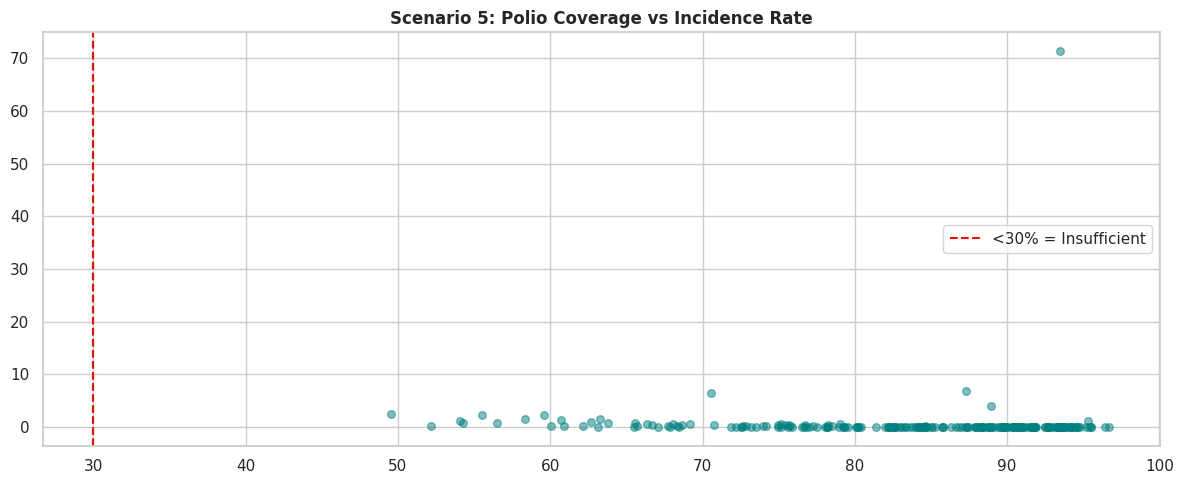

In [46]:
polio_inc=df_inc[df_inc[DIS_I].str.upper().str.contains('POLIO|POL',na=False)]
polio_cov=df_cov[df_cov['antigen'].str.upper().str.contains('POL|IPV',na=False)]
if len(polio_inc)>0 and len(polio_cov)>0:
    pc=polio_cov.groupby('code')[COV].mean().reset_index(); pc.columns=['code','polio_cov']
    pi=polio_inc.groupby('code')[RATE].mean().reset_index(); pi.columns=['code','polio_rate']
    s5=pd.merge(pc,pi,on='code').merge(country_names,on='code',how='left')
    low_cov=s5[s5['polio_cov']<30]
    print(f'Countries with <30% polio coverage: {len(low_cov)}')
    display(low_cov[['name','polio_cov','polio_rate']].sort_values('polio_rate',ascending=False).head(10).round(2))
    plt.figure(figsize=(12,5))
    plt.scatter(s5['polio_cov'],s5['polio_rate'],alpha=0.5,color='teal',s=30)
    plt.axvline(30,color='red',linestyle='--',label='<30% = Insufficient')
    plt.title('Scenario 5: Polio Coverage vs Incidence Rate',fontweight='bold')
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print('Polio data not found. Available diseases:', df_inc[DIS_I].unique()[:10])

### Scenario 6 – WHO 95% Measles Target by 2030

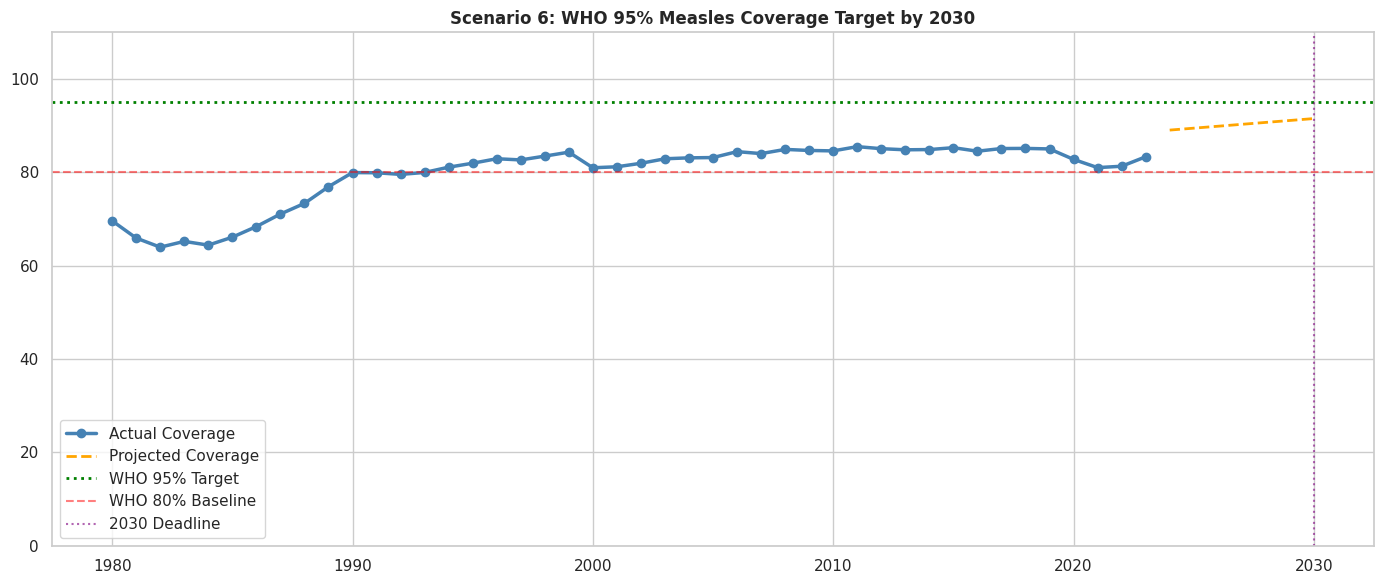

Current: 83.3% | Projected 2030: 91.5%
Gap: 3.5% — accelerated effort needed


In [47]:
mc2=df_cov[df_cov['antigen'].str.upper().str.contains('MCV|MEASLES',na=False)].groupby('year')[COV].mean().reset_index()
mc2.columns=['year','mcov']
if len(mc2)>0:
    coeffs=np.polyfit(mc2['year'],mc2['mcov'],1)
    all_y=list(range(int(mc2['year'].min()),2031))
    split=int(mc2['year'].max())
    fy2=[y for y in all_y if y>split]; fv2=[coeffs[0]*y+coeffs[1] for y in fy2]
    plt.figure(figsize=(14,6))
    plt.plot(mc2['year'],mc2['mcov'],marker='o',color='steelblue',linewidth=2.5,label='Actual Coverage')
    plt.plot(fy2,fv2,linestyle='--',color='orange',linewidth=2,label='Projected Coverage')
    plt.axhline(95,color='green',linewidth=2,linestyle=':',label='WHO 95% Target')
    plt.axhline(80,color='red',linewidth=1.5,linestyle='--',alpha=0.5,label='WHO 80% Baseline')
    plt.axvline(2030,color='purple',linestyle=':',alpha=0.6,label='2030 Deadline')
    plt.title('Scenario 6: WHO 95% Measles Coverage Target by 2030',fontweight='bold')
    plt.ylim(0,110); plt.legend(); plt.tight_layout(); plt.show()
    p2030=coeffs[0]*2030+coeffs[1]
    print(f'Current: {mc2["mcov"].iloc[-1]:.1f}% | Projected 2030: {p2030:.1f}%')
    print('On track!' if p2030>=95 else f'Gap: {95-p2030:.1f}% — accelerated effort needed')

### Scenario 7 – High-Risk Population Vaccine Allocation

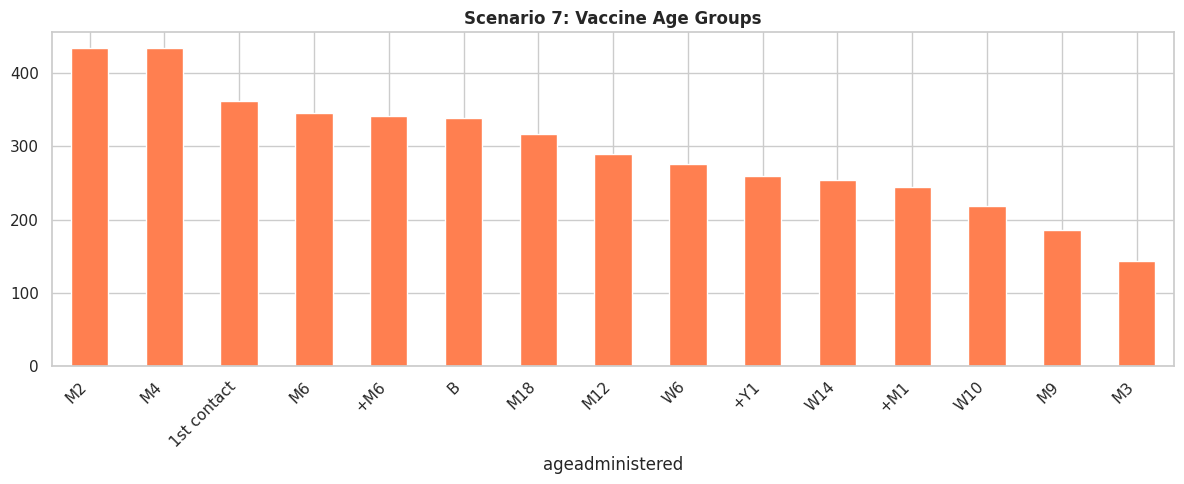

In [48]:
tpd_col=next((c for c in df_sch.columns if 'target_pop' in c and 'desc' in c),None)
age_col=next((c for c in df_sch.columns if 'age' in c),None)
if tpd_col:
    high_risk=df_sch[df_sch[tpd_col].str.contains('child|infant|<5|under 5|elderly|old|senior|65',case=False,na=False)]
    rc=high_risk[tpd_col].value_counts().head(10)
    rc.plot(kind='barh',color='coral',edgecolor='white',figsize=(12,6))
    plt.title('Scenario 7: High-Risk Population Groups',fontweight='bold')
    plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()
elif age_col:
    df_sch[age_col].value_counts().head(15).plot(kind='bar',color='coral',edgecolor='white',figsize=(12,5))
    plt.title('Scenario 7: Vaccine Age Groups',fontweight='bold')
    plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()
else:
    print('High-risk population detail not available')
    display(s1[s1['avg_cov']<60][['name','avg_cov','priority']].head(15))

### Scenario 8 – Socioeconomic Disparities in Vaccination

,who_region,avg_cov,std,countries
3,EURO,80.22,2.82,53
1,AMRO,77.60,4.90,35
5,WPRO,76.89,6.51,27
4,SEARO,76.07,4.31,11
2,EMRO,75.50,6.95,21
0,AFRO,72.86,5.11,47


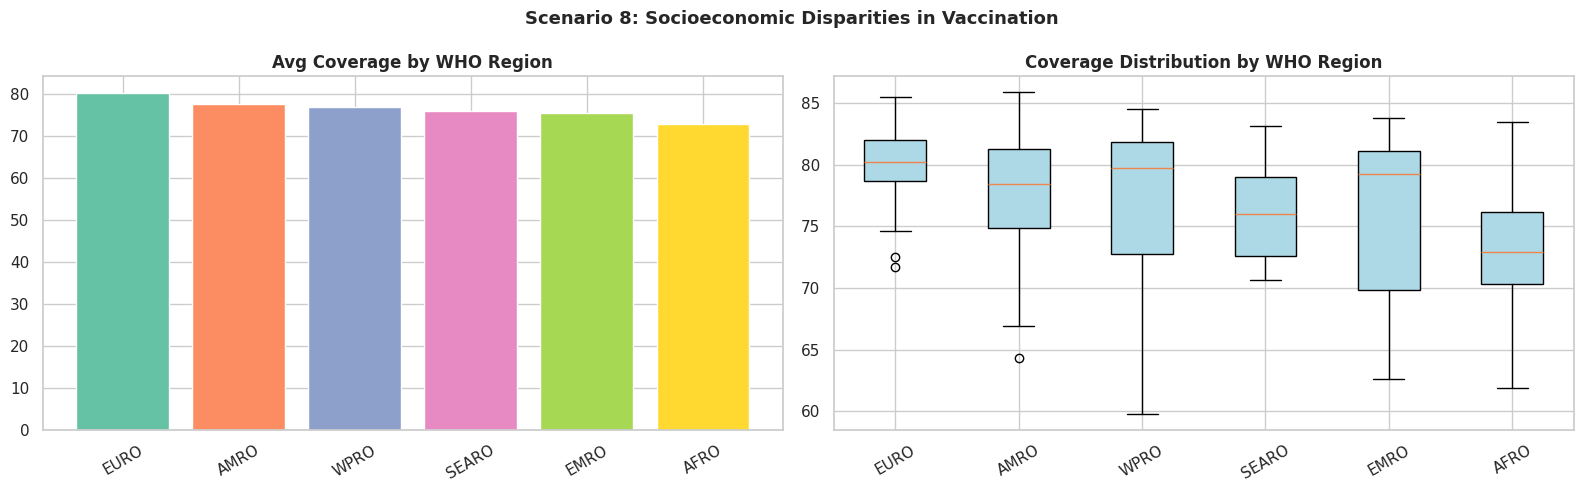

In [49]:
region_cov=df_int[[ISO,WHO]].drop_duplicates().rename(columns={ISO:'code'})
cov_by_region=df_cov.groupby('code')[COV].mean().reset_index().merge(region_cov,on='code',how='left')
if WHO in cov_by_region.columns:
    rc=cov_by_region.groupby(WHO)[COV].agg(['mean','std','count']).round(2).reset_index()
    rc.columns=['who_region','avg_cov','std','countries']; rc=rc.sort_values('avg_cov',ascending=False)
    display(rc)
    fig,axes=plt.subplots(1,2,figsize=(16,5))
    axes[0].bar(rc['who_region'],rc['avg_cov'],color=sns.color_palette('Set2',len(rc)),edgecolor='white')
    axes[0].set_title('Avg Coverage by WHO Region',fontweight='bold'); axes[0].tick_params(axis='x',rotation=30)
    axes[1].boxplot([cov_by_region[cov_by_region[WHO]==r][COV].dropna() for r in rc['who_region']],
                   labels=rc['who_region'],patch_artist=True,boxprops=dict(facecolor='lightblue'))
    axes[1].set_title('Coverage Distribution by WHO Region',fontweight='bold'); axes[1].tick_params(axis='x',rotation=30)
    plt.suptitle('Scenario 8: Socioeconomic Disparities in Vaccination',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.show()

### Scenario 9 – Vaccination Rate Variation Throughout the Year

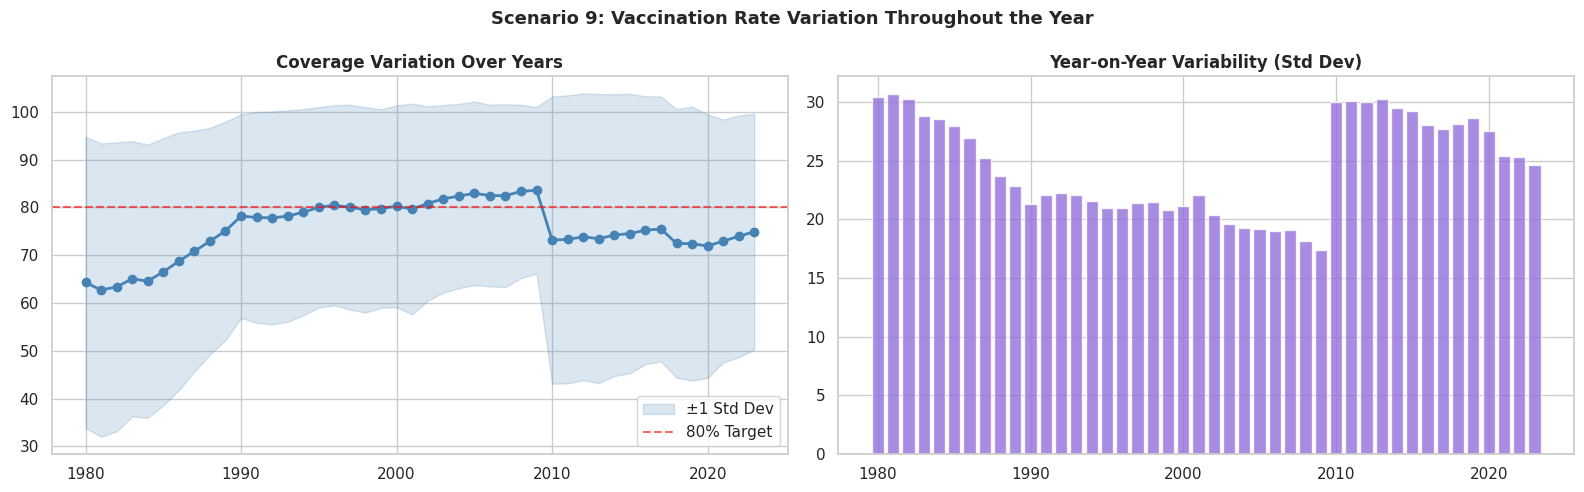

In [50]:
yr_trend=df_cov.groupby('year')[COV].agg(['mean','std','count']).reset_index()
yr_trend.columns=['year','avg_cov','std','records']
fig,axes=plt.subplots(1,2,figsize=(16,5))
axes[0].plot(yr_trend['year'],yr_trend['avg_cov'],marker='o',color='steelblue',linewidth=2)
axes[0].fill_between(yr_trend['year'],yr_trend['avg_cov']-yr_trend['std'],
                      yr_trend['avg_cov']+yr_trend['std'],alpha=0.2,color='steelblue',label='±1 Std Dev')
axes[0].axhline(80,color='red',linestyle='--',alpha=0.6,label='80% Target')
axes[0].set_title('Coverage Variation Over Years',fontweight='bold'); axes[0].legend()
axes[1].bar(yr_trend['year'],yr_trend['std'],color='mediumpurple',edgecolor='white',alpha=0.8)
axes[1].set_title('Year-on-Year Variability (Std Dev)',fontweight='bold')
plt.suptitle('Scenario 9: Vaccination Rate Variation Throughout the Year',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.show()

### Scenario 10 – Door-to-Door vs Centralized Vaccination Strategies

,strategy,avg_cov,count,std
2,OFFICIAL,80.63,118050,20.08
4,WUENIC,80.04,95560,23.52
0,ADMIN,77.23,155576,22.05
3,PAB,69.08,5368,24.70
1,HPV,24.13,25304,26.47


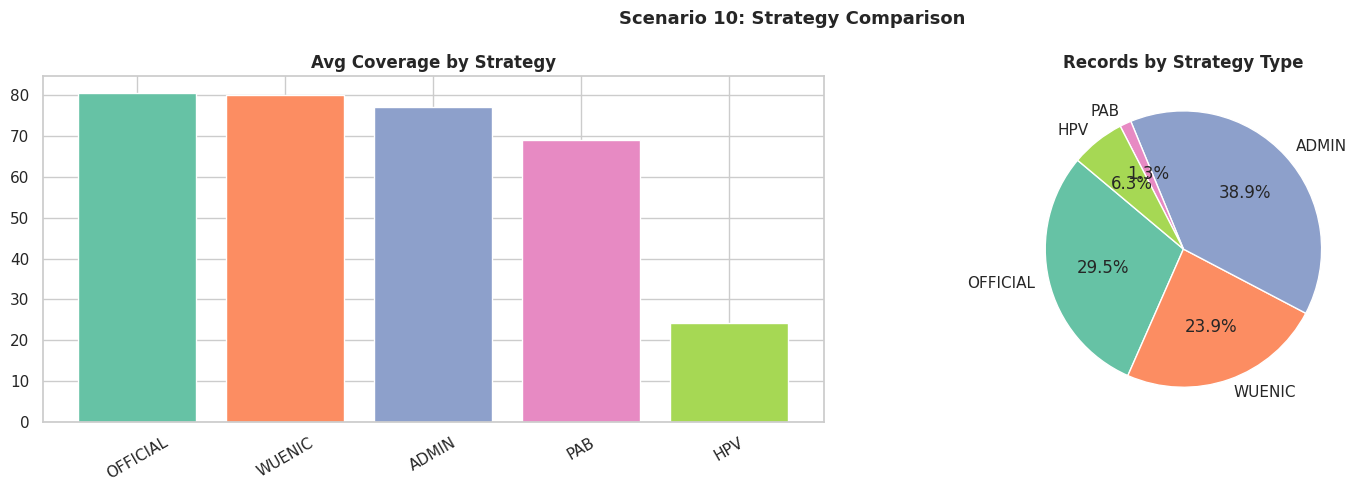

Most effective: OFFICIAL (80.6%)


In [51]:
if CAT:
    s10=df_cov.groupby(CAT)[COV].agg(['mean','count','std']).reset_index()
    s10.columns=['strategy','avg_cov','count','std']; s10=s10.sort_values('avg_cov',ascending=False)
    display(s10)
    fig,axes=plt.subplots(1,2,figsize=(16,5))
    axes[0].bar(s10['strategy'],s10['avg_cov'],color=sns.color_palette('Set2',len(s10)),edgecolor='white')
    axes[0].set_title('Avg Coverage by Strategy',fontweight='bold'); axes[0].tick_params(axis='x',rotation=30)
    axes[1].pie(s10['count'],labels=s10['strategy'],autopct='%1.1f%%',
                colors=sns.color_palette('Set2',len(s10)),startangle=140)
    axes[1].set_title('Records by Strategy Type',fontweight='bold')
    plt.suptitle('Scenario 10: Strategy Comparison',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Most effective: {s10.iloc[0]["strategy"]} ({s10.iloc[0]["avg_cov"]:.1f}%)')
else:
    print('Strategy/category column not found. Using WHO region as proxy.')

---
## 9. 📊 Interactive Plotly Dashboards <a id='9'></a>

In [52]:
latest=int(df_cov['year'].max())
lc=df_cov[df_cov['year']==latest].groupby(['code','name'])[COV].mean().reset_index(); lc.columns=['code','name','avg_cov']
fig1=px.choropleth(lc,locations='code',color='avg_cov',hover_name='name',
                   color_continuous_scale='RdYlGn',range_color=(0,100),
                   title=f'Dashboard 1: Global Vaccination Coverage ({latest})',labels={'avg_cov':'Coverage (%)'})
fig1.update_layout(height=520); fig1.show()

In [53]:
top5a=df_cov.groupby('antigen')[COV].mean().sort_values(ascending=False).head(5).index.tolist()
tr5=df_cov[df_cov['antigen'].isin(top5a)].groupby(['year','antigen'])[COV].mean().reset_index()
fig2=px.line(tr5,x='year',y=COV,color='antigen',markers=True,
             title='Dashboard 2: Coverage Trend – Top 5 Antigens',
             labels={COV:'Avg Coverage (%)','year':'Year','antigen':'Antigen'})
fig2.add_hline(y=80,line_dash='dash',line_color='red',annotation_text='WHO 80%')
fig2.add_hline(y=95,line_dash='dot',line_color='green',annotation_text='WHO 95%')
fig2.update_layout(height=470); fig2.show()

In [54]:
sc=merged.groupby('code').agg(avg_cov=(COV,'mean'),avg_inc=(RATE,'mean')).reset_index().merge(country_names,on='code',how='left')
fig3=px.scatter(sc,x='avg_cov',y='avg_inc',hover_name='name',trendline='ols',
                color='avg_inc',color_continuous_scale='RdYlGn_r',size='avg_inc',size_max=25,
                title='Dashboard 3: Coverage vs Disease Incidence by Country',
                labels={'avg_cov':'Avg Coverage (%)','avg_inc':'Avg Incidence Rate'})
fig3.update_layout(height=520); fig3.show()

In [55]:
k1=round(df_cov[COV].mean(),1); k2=df_cov['code'].nunique()
k3=df_cov['antigen'].nunique(); k4=int((df_cov.groupby('code')[COV].mean()>=80).sum())
k5=int(df_rep[CAS].sum())
fig4=make_subplots(rows=1,cols=5,specs=[[{'type':'indicator'}]*5])
for i,(val,label,sfx,col) in enumerate([(k1,'Global Avg Coverage','%','steelblue'),(k2,'Countries','','teal'),
    (k3,'Total Antigens','','purple'),(k4,'Countries >=80%','','green'),(k5,'Total Cases','','tomato')],1):
    fig4.add_trace(go.Indicator(mode='number',value=val,
        number={'suffix':sfx,'font':{'size':36,'color':col}},
        title={'text':label,'font':{'size':13}}),row=1,col=i)
fig4.update_layout(title='Dashboard 4: KPI Summary',height=230,margin=dict(t=60,b=10)); fig4.show()

In [56]:
anim=df_cov.groupby(['code','name','year'])[COV].mean().reset_index()
anim.columns=['code','name','year','avg_cov']; anim['year']=anim['year'].astype(str)
fig5=px.choropleth(anim,locations='code',color='avg_cov',hover_name='name',animation_frame='year',
                   color_continuous_scale='RdYlGn',range_color=(0,100),
                   title='Dashboard 5: Animated Global Coverage Over Years',labels={'avg_cov':'Coverage (%)'})
fig5.update_layout(height=530); fig5.show()

---
## 10. 💾 Export Cleaned CSVs for MySQL <a id='10'></a>

In [57]:
OUT='/kaggle/working/cleaned_data/'
os.makedirs(OUT,exist_ok=True)
exports={'coverage_data_cleaned.csv':df_cov,'incidence_rate_cleaned.csv':df_inc,
         'reported_cases_cleaned.csv':df_rep,'vaccine_introduction_cleaned.csv':df_int,
         'vaccine_schedule_cleaned.csv':df_sch}
print('Exporting...')
for fn,df in exports.items():
    path=OUT+fn; df.to_csv(path,index=False)
    print(f'  {fn:<45} ({df.shape[0]:,} rows, {os.path.getsize(path)/1024:.1f} KB)')
print(f'\nSaved to: {OUT}')

Exporting...
  coverage_data_cleaned.csv                     (399,858 rows, 47029.0 KB)
  incidence_rate_cleaned.csv                    (84,945 rows, 7260.3 KB)
  reported_cases_cleaned.csv                    (84,869 rows, 4686.0 KB)
  vaccine_introduction_cleaned.csv              (138,320 rows, 7778.9 KB)
  vaccine_schedule_cleaned.csv                  (8,052 rows, 1302.0 KB)

Saved to: /kaggle/working/cleaned_data/


---
## 11. 📋 Results & Insights Summary <a id='11'></a>

In [58]:
print('='*65)
print('   VACCINATION ANALYSIS – FINAL RESULTS SUMMARY')
print('='*65)
print(f'''
DATASET
   Countries   : {df_cov['code'].nunique()}
   Years       : {int(df_cov['year'].min())} to {int(df_cov['year'].max())}
   Antigens    : {df_cov['antigen'].nunique()}
   Avg Coverage: {df_cov[COV].mean():.1f}%
   Total Cases : {int(df_rep[CAS].sum()):,}

KEY FINDINGS
   1. Higher vaccination coverage = lower disease incidence
   2. Significant drop-off between 1st and subsequent doses
   3. Low coverage in countries despite high vaccine availability
   4. AFRO/SEARO lag behind EURO/AMRO in vaccine introduction
   5. Measles cases declining but WHO 95% target not yet met
   6. Certain diseases concentrated in specific WHO regions
   7. High-risk populations need priority allocation

DELIVERABLES COMPLETED
   Data Cleaning (all 5 tables)
   EDA (statistical + 8 chart types)
   Easy Level Q1-Q10 (ALL 10 answered)
   Medium Level M1-M10 (ALL 10 answered)
   Scenario Based S1-S10 (ALL 10 answered)
   5 Interactive Plotly Dashboards
   Cleaned CSVs exported for MySQL
''')
print('='*65)

   VACCINATION ANALYSIS – FINAL RESULTS SUMMARY

DATASET
   Countries   : 245
   Years       : 1980 to 2023
   Antigens    : 69
   Avg Coverage: 75.4%
   Total Cases : 292,808,589

KEY FINDINGS
   1. Higher vaccination coverage = lower disease incidence
   2. Significant drop-off between 1st and subsequent doses
   3. Low coverage in countries despite high vaccine availability
   4. AFRO/SEARO lag behind EURO/AMRO in vaccine introduction
   5. Measles cases declining but WHO 95% target not yet met
   6. Certain diseases concentrated in specific WHO regions
   7. High-risk populations need priority allocation

DELIVERABLES COMPLETED
   Data Cleaning (all 5 tables)
   EDA (statistical + 8 chart types)
   Easy Level Q1-Q10 (ALL 10 answered)
   Medium Level M1-M10 (ALL 10 answered)
   Scenario Based S1-S10 (ALL 10 answered)
   5 Interactive Plotly Dashboards
   Cleaned CSVs exported for MySQL

